<div align="center">

# Notebook 5 *reservoirpy* Upgrade

# Classification multi-class FOCH

**Branche Dual pour la classification**

![Python](https://img.shields.io/badge/Python-3.10+-blue?style=flat-square&logo=python)
![PyTorch](https://img.shields.io/badge/PyTorch-2.0+-EE4C2C?style=flat-square&logo=pytorch)
![HuggingFace](https://img.shields.io/badge/🤗-Transformers-FFD21F?style=flat-square)
![CUDA](https://img.shields.io/badge/CUDA-AMP%20Enabled-76B900?style=flat-square&logo=nvidia)

</div>


## Synthèse de l'architecture configurable (upgrade notebook 5)

Cet upgrade rend l'architecture **entièrement pilotable par configuration**, pour comparer plusieurs backbones audio-domaine *sans réécrire la boucle d'entraînement*. Cible : battre la baseline du notebook 5 (**CNN14, 75.2 %, K=5 CV**).

**1 — Backbone configurable (`BACKBONE`, Cellule 1).** Un preset unique sélectionne la/les branche(s) ; la tête de fusion s'adapte automatiquement à la dimension d'embedding, et `forward(input_values, spec)` reste inchangé.

| Preset | Branche audio-domaine (AudioSet) | Branche WavLM | Fusion |
|---|---|---|---|
| `cnn14` *(défaut)* | CNN14 entraînable (2048-d) | WavLM-Base gelé (768-d) | 2816-d |
| `ast` | AST gelé (768-d) | WavLM-Base gelé (768-d) | 1536-d |
| `cnn14_solo` / `ast_solo` | CNN14 / AST seul | — | 2048 / 768-d |
| `wavlm_base` / `wavlm_large` | — | WavLM Base / Large gelé | 768 / 1024-d |

**2 — Gel de WavLM.** Gelé par défaut (`FREEZE_WAVLM=True`, config du meilleur résultat). **Dégel tardif et partiel** optionnel (`UNFREEZE_ENABLED`) : uniquement les `UNFREEZE_LAST_N` dernières couches, à partir de l'époque `UNFREEZE_AT_EPOCH` (≥ 20), à LR discriminant réduit — un petit jeu (~265 enregistrements) ne peut pas remodeler 95–300M paramètres sans dégrader la baseline gelée.

**3 — AST + budget mémoire.** AST chargé **en local** (`ast-finetuned-audioset-10-10-0.4593`), gelé, avec un fbank interne fixe (1024×128) indépendant de la fenêtre. L'arbitrage **fenêtre ↔ batch** est absorbé par l'accumulation de gradient (batch effectif ≈ 16) ; la **sonde VRAM (Cellule 6b)** dimensionne `BATCH_SIZE` — mesuré ≈ 0.27 Go/éch. (`cnn14`+WavLM-Base) → 8 Go : `BATCH_SIZE` 8 ; RTX 5070 Ti 16 Go : 16-24.

> Les explications détaillées accompagnent chaque section (Cellules 1, 6, 6b, 7).

## 1. Configuration de l'environnement et des chemins

Cette première section centralise les dépendances, les chemins **et la sélection du backbone**. Le notebook met en œuvre un **classifieur multi-branche configurable** évalué par **validation croisée stratifiée à 5 plis** (`StratifiedKFold`), avec **augmentation de données injectée pli par pli dans le seul jeu d'entraînement**.

**Classes retenues :**

| Classe | Origine | Justification |
|---|---|---|
| `PR` | FOCH | Pathologie majoritaire (support le plus élevé) |
| `LMB` | FOCH | Support intermédiaire |
| `fuite glottique` | FOCH | Support intermédiaire |
| `Healthy` | Saarbruecken (SVD) | Groupe contrôle — voyelle /a/ à hauteur habituelle |

La classe `Cancer` reste **exclue** (support insuffisant, n ≈ 26). Le déséquilibre des trois pathologies est compensé par des **signaux augmentés** injectés **exclusivement dans le train de chaque pli** ; le pli de validation reste strictement original.

### Sélection configurable du backbone (`BACKBONE`)

Le problème est plus proche de l'**analyse bioacoustique / de signal pathologique** que de la reconnaissance de parole ; on privilégie donc des backbones **audio-domaine pré-entraînés sur AudioSet** plutôt que des modèles centrés parole. Le drapeau `BACKBONE` sélectionne un preset ; le reste du notebook (Dataset, modèle, boucle) s'adapte automatiquement aux dimensions d'embedding.

| Preset | Branche audio-domaine | Branche WavLM | Fusion |
|---|---|---|---|
| `cnn14` *(défaut)* | **CNN14** (PANNs/AudioSet, entraînable, 2048-d) | WavLM-Base gelé (768-d) | 2816-d |
| `ast` | **AST** (AudioSet, ViT spectral, gelé, 768-d) | WavLM-Base gelé (768-d) | 1536-d |
| `cnn14_solo` | CNN14 seul | — | 2048-d |
| `ast_solo` | AST seul | — | 768-d |
| `wavlm_base` | — | WavLM-Base gelé | 768-d |
| `wavlm_large` | — | WavLM-Large gelé (ancienne config nb 6) | 1024-d |

> 💡 **Choix WavLM-Base plutôt que Large** — la branche WavLM apporte le détail acoustique microscopique (jitter, shimmer, apériodicité). On retient la variante **Base** (95M) : dégeler/affiner 300M+ paramètres (Large) n'est pas justifié par la taille du jeu ni le budget de calcul. WavLM restant **gelé** par défaut, Base suffit ; Large reste sélectionnable (`wavlm_large`) au prix d'une VRAM plus élevée.

### Stratégie de gel de WavLM (résumé)

Par défaut `FREEZE_WAVLM=True` (embeddings gelés) — c'est la configuration du meilleur résultat obtenu jusqu'ici (**75.2 %**, WavLM gelé + planificateur LR, sans dégel). Un **dégel tardif partiel** optionnel (`UNFREEZE_ENABLED`) n'affine que les `UNFREEZE_LAST_N` dernières couches transformer, et seulement à partir de l'époque `UNFREEZE_AT_EPOCH`. Détails et justification en Cellule 6.

### Arbitrage fenêtre ↔ taille de batch

La **fenêtre audio** (`MAX_LEN_S`) fixe la résolution temporelle du spectrogramme Mel de CNN14 (`T = MAX_LEN/HOP + 1`). Une fenêtre plus **longue** = plus de trames = **plus de VRAM par échantillon**, ce qui force un **batch physique plus petit** (source d'instabilité de gradient constatée au notebook 6 avec un batch de 2). Deux leviers :

- **Accumulation de gradient** (`ACCUM_STEPS`) — conserve un **batch effectif** ≈ 16 même quand la VRAM impose un `BATCH_SIZE` de 2-4.
- **Chemin AST** — AST calcule un banc de filtres **interne de taille fixe** (1024×128) indépendant de `MAX_LEN_S` ; comme il est de plus **gelé** (pas d'activations à rétropropager dans ses 12 couches), il relâche fortement la contrainte VRAM par rapport à un WavLM-Large fine-tuné.

Repères VRAM **mesurés** (sonde 6b, `cnn14`+WavLM-Base, fenêtre 4 s ≈ **0.27 Go/échantillon**) : **8 Go** → `BATCH_SIZE` **8** confortable (bien au-delà du batch=2 du notebook 6 ; retomber à 4 si WavLM-Large gelé) ; **RTX 5070 Ti 16 Go** → 16-24 avec `ACCUM_STEPS`=1. Poids et métriques sont sauvegardés dans `.poids_modèles` et `.foch_métriques`.

In [26]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 1 — Imports, configuration des chemins et hyperparamètres
# ═══════════════════════════════════════════════════════════════════════════
import os
import gc
import glob
import random
import warnings

import numpy as np
import pandas as pd
import torch
import torchaudio
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')

# ── Reproductibilité ─────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── FFmpeg (backend de décodage audio pour torchaudio) ───────────────────────
import shutil
_ffmpeg_bin = r'C:/Users/AdminIA/Downloads/ffmpeg-8.1.1-full_build-shared/ffmpeg-8.1.1-full_build-shared/bin'
if os.path.isdir(_ffmpeg_bin):
    os.environ['PATH'] += os.pathsep + _ffmpeg_bin
print(f'FFmpeg : {shutil.which("ffmpeg")}')

# ── Chemins des données ──────────────────────────────────────────────────────
CSV_PATH        = r'C:/Users/AdminIA/Desktop/ORL_IA_FOCH_Callum_HOLLIDAY/csv_best/orl_df_vowel_master.csv'
FOCH_AUDIO_DIR  = r'C:/Users/AdminIA/Desktop/ORL_IA_FOCH_Callum_HOLLIDAY/Segmented_Voyelles_Best'
SVD_HEALTHY_DIR = r'C:/Users/AdminIA/Documents/SVD/healthy'

# ── Données augmentées ────────────────────────────────────────────────────────
AUG_DIR         = r'C:/Users/AdminIA/Desktop/ORL_IA_FOCH_Callum_HOLLIDAY/Segmented_Voyelles_Augmented'
AUG_SIGNAL_DIR  = os.path.join(AUG_DIR, 'signal')
AUG_MANIFESTS   = [
    os.path.join(AUG_DIR, 'manifest_train_bal.csv'),
    os.path.join(AUG_DIR, 'manifest_train_bal_vc.csv'),
]

# ═══════════════════════════════════════════════════════════════════════════
# SÉLECTION CONFIGURABLE DU BACKBONE  (cf. Cellule 6 pour le modèle)
# ═══════════════════════════════════════════════════════════════════════════
# Le classifieur est un réseau MULTI-BRANCHE. On sépare deux rôles :
#   • une branche « audio-domaine » (spectrale), au choix CNN14 ou AST, toutes
#     deux pré-entraînées sur AudioSet → adaptées à l'analyse bioacoustique /
#     pathologique du signal plutôt qu'à la reconnaissance de parole ;
#   • une branche WavLM OPTIONNELLE (détail acoustique fin : jitter/shimmer),
#     en variante Base (défaut) plutôt que Large — cf. stratégie de gel ci-dessous.
#
# On sélectionne un preset unique ; le reste du notebook (Dataset, modèle, boucle
# d'entraînement) s'adapte automatiquement aux dimensions d'embedding.
#
#   'cnn14'       → CNN14 (PANNs/AudioSet)        + WavLM-Base gelé   [DÉFAUT]
#   'ast'         → AST (AudioSet, ViT spectral)  + WavLM-Base gelé
#   'cnn14_solo'  → CNN14 seul   (pas de WavLM)
#   'ast_solo'    → AST seul     (pas de WavLM)
#   'wavlm_base'  → WavLM-Base seul (pas de branche spectrale)
#   'wavlm_large' → WavLM-Large seul (ancienne config notebook 6 ; gelé)
#
BACKBONE = 'cnn14'

_BACKBONE_PRESETS = {
    'cnn14':       {'audio': 'cnn14', 'wavlm': 'base'},
    'ast':         {'audio': 'ast',   'wavlm': 'base'},
    'cnn14_solo':  {'audio': 'cnn14', 'wavlm': None},
    'ast_solo':    {'audio': 'ast',   'wavlm': None},
    'wavlm_base':  {'audio': None,    'wavlm': 'base'},
    'wavlm_large': {'audio': None,    'wavlm': 'large'},
}
assert BACKBONE in _BACKBONE_PRESETS, f'BACKBONE inconnu : {BACKBONE} (choix : {list(_BACKBONE_PRESETS)})'
AUDIO_BACKBONE = _BACKBONE_PRESETS[BACKBONE]['audio']    # 'cnn14' | 'ast' | None
WAVLM_VARIANT  = _BACKBONE_PRESETS[BACKBONE]['wavlm']    # 'base'  | 'large' | None

# ── Chemins locaux des backbones ─────────────────────────────────────────────
WAVLM_DIRS = {
    'base':  r'C:/Users/AdminIA/Documents/models/wavlm-base',
    'large': r'C:/Users/AdminIA/Documents/models/wavlm-large',
}
AST_DIR     = r'C:/Users/AdminIA/Documents/models/ast-finetuned-audioset-10-10-0.4593'  # chargé en LOCAL
WAVLM_DIR   = WAVLM_DIRS.get(WAVLM_VARIANT)             # None si pas de branche WavLM
MODEL_DIR   = WAVLM_DIR or WAVLM_DIRS['base']           # dir du processor WavLM (rétro-compat)
WAVLM_EMB_DIM = {'base': 768, 'large': 1024, None: 0}[WAVLM_VARIANT]
AST_EMB_DIM   = 768

# ── Poids CNN14 pré-entraînés — stratégie de chargement ──────────────────────
CNN14_CKPT_PATH  = r'C:/Users/AdminIA/Documents/models/cnn14-esc50/embedding_model.ckpt'  # chemin LOCAL du checkpoint CNN14
CNN14_PRETRAINED = True   # mettre False pour ignorer tout chargement de poids
CNN14_EMB_DIM    = 2048

# ── AST : gel par défaut (86M params ViT → non affinables sur ~265 échantillons) ─
FREEZE_AST = True         # AST utilisé comme extracteur d'embeddings (pooler 768-d)

# ── Artefacts de sortie ──────────────────────────────────────────────────────
WEIGHTS_DIR = r'C:/Users/AdminIA/Documents/models/.poids_modèles'
METRICS_DIR = r'C:/Users/AdminIA/Documents/models/.foch_métriques'
os.makedirs(WEIGHTS_DIR, exist_ok=True)
os.makedirs(METRICS_DIR, exist_ok=True)
RUN_NAME = f'{BACKBONE}_kfold_aug'

# ── Définition des classes ───────────────────────────────────────────────────
TARGET_PATHOLOGIES = ['PR', 'LMB', 'fuite glottique']
HEALTHY_LABEL      = 'Healthy'
CLASSES            = TARGET_PATHOLOGIES + [HEALTHY_LABEL]
NUM_LABELS         = len(CLASSES)
N_HEALTHY          = 100

# ── Validation croisée ────────────────────────────────────────────────────────
K_FOLDS      = 5

# ── Hyperparamètres audio ─────────────────────────────────────────────────────
# La FENÊTRE (MAX_LEN_S) fixe la résolution temporelle du spectrogramme CNN14
# (T = MAX_LEN/HOP+1). Une fenêtre plus longue = plus de trames = plus de VRAM
# par échantillon → force un batch plus petit. Voir la note markdown ci-dessus
# sur l'arbitrage fenêtre ↔ batch. AST ignore cette config (fbank interne fixe
# 1024×128) et pardonne donc mieux les fenêtres longues.
TARGET_SR    = 16000
MAX_LEN_S    = 4.0
MAX_LEN      = int(TARGET_SR * MAX_LEN_S)
N_FFT        = 1024
HOP_LENGTH   = 256
N_MELS       = 128
MEL_FRAMES   = MAX_LEN // HOP_LENGTH + 1

# ── Hyperparamètres d'entraînement ────────────────────────────────────────────
# Budget mémoire (MESURÉ par la sonde VRAM, Cellule 6b) :
#   • cnn14 + WavLM-Base gelé, fenêtre 4s : ~0.27 Go/échantillon (1 pas fwd+bwd).
#   • Portable 8 Go VRAM  : BATCH_SIZE=8 confortable (cnn14/ast + WavLM-Base) —
#     bien au-delà du batch=2 du notebook 6 (source d'instabilité). Retomber à 4
#     seulement si WavLM-Large gelé est sélectionné, ou en cas d'OOM.
#   • RTX 5070 Ti 16 Go   : BATCH_SIZE 16-24 → ACCUM_STEPS 1 (plus besoin d'accum).
# Le batch EFFECTIF (BATCH_SIZE × ACCUM_STEPS) reste la grandeur qui stabilise
# l'entraînement ; l'accumulation le maintient à ~16 même si la VRAM impose un
# petit BATCH_SIZE physique. Relancer la sonde 6b après un changement de
# BACKBONE / MAX_LEN_S / BATCH_SIZE.
BATCH_SIZE      = 8
ACCUM_STEPS     = 2          # batch effectif = BATCH_SIZE × ACCUM_STEPS = 16
EPOCHS          = 30
LR              = 1e-5
WEIGHT_DECAY    = 0.01
PATIENCE        = 6
DROPOUT         = 0.4
HIDDEN_DIM      = 512

# ── Stratégie de gel / dégel de WavLM (cf. Cellule 6 & note markdown) ────────
# Par défaut WavLM reste GELÉ (embeddings) — c'est la config du meilleur résultat
# (75.2 % avec WavLM gelé + planificateur LR, sans dégel). Le dégel tardif partiel
# est OPTIONNEL : ne dégeler que les dernières couches, et seulement à partir de
# l'époque UNFREEZE_AT_EPOCH (jamais dès le départ).
FREEZE_WAVLM       = False    # WavLM gelé par défaut
UNFREEZE_ENABLED   = True   # activer le dégel tardif partiel
UNFREEZE_AT_EPOCH  = 20      # époque de départ du dégel (>= 20 conseillé)
UNFREEZE_LAST_N    = 3       # nb de couches transformer finales à dégeler (3-4)
UNFREEZE_LR        = 1e-5    # LR discriminant réduit pour les couches dégelées

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Résumé de la configuration ───────────────────────────────────────────────
_dims = []
if WAVLM_VARIANT:              _dims.append(('WavLM-' + WAVLM_VARIANT, WAVLM_EMB_DIM))
if AUDIO_BACKBONE == 'cnn14':  _dims.append(('CNN14', CNN14_EMB_DIM))
elif AUDIO_BACKBONE == 'ast':  _dims.append(('AST', AST_EMB_DIM))
FUSION_DIM_EXPECTED = sum(d for _, d in _dims)

if not CNN14_PRETRAINED:
    _cnn14_status = 'initialisation ALÉATOIRE (CNN14_PRETRAINED=False)'
elif CNN14_CKPT_PATH and os.path.isfile(CNN14_CKPT_PATH):
    _cnn14_status = f'chemin LOCAL → {CNN14_CKPT_PATH}'
else:
    _cnn14_status = 'téléchargement réseau (miroir hf-mirror.com → HuggingFace Hub)'

print('Configuration chargée.')
print(f'  Preset backbone : {BACKBONE}  (audio={AUDIO_BACKBONE}, wavlm={WAVLM_VARIANT})')
print(f'  Classes ({NUM_LABELS}) : {CLASSES}')
print(f'  Healthy cible   : {N_HEALTHY} (sous-échantillonné)')
print(f'  Validation      : StratifiedKFold à {K_FOLDS} plis')
print(f'  Fenêtre audio   : {MAX_LEN_S}s ({MAX_LEN} éch.) | Mel ({N_MELS}, {MEL_FRAMES})')
print(f'  Branches actives: {" + ".join(f"{n}({d})" for n, d in _dims)} → fusion {FUSION_DIM_EXPECTED}-d')
print(f'  Batch           : {BATCH_SIZE} × {ACCUM_STEPS} (accum) = {BATCH_SIZE * ACCUM_STEPS} effectif')
print(f'  WavLM           : {"gelé" if FREEZE_WAVLM else "entraînable"}'
      + (f' | dégel tardif ON (>= epoch {UNFREEZE_AT_EPOCH}, {UNFREEZE_LAST_N} couches)' if UNFREEZE_ENABLED else ' | dégel OFF'))
if AUDIO_BACKBONE == 'cnn14':
    print(f'  CNN14 poids     : {_cnn14_status}')
elif AUDIO_BACKBONE == 'ast':
    print(f'  AST             : {"gelé" if FREEZE_AST else "entraînable"} ← {AST_DIR}')
print(f'  Device          : {device}')

FFmpeg : C:/Users/AdminIA/Downloads/ffmpeg-8.1.1-full_build-shared/ffmpeg-8.1.1-full_build-shared/bin\ffmpeg.EXE
Configuration chargée.
  Preset backbone : cnn14  (audio=cnn14, wavlm=base)
  Classes (4) : ['PR', 'LMB', 'fuite glottique', 'Healthy']
  Healthy cible   : 100 (sous-échantillonné)
  Validation      : StratifiedKFold à 5 plis
  Fenêtre audio   : 4.0s (64000 éch.) | Mel (128, 251)
  Branches actives: WavLM-base(768) + CNN14(2048) → fusion 2816-d
  Batch           : 8 × 2 (accum) = 16 effectif
  WavLM           : entraînable | dégel tardif ON (>= epoch 20, 3 couches)
  CNN14 poids     : chemin LOCAL → C:/Users/AdminIA/Documents/models/cnn14-esc50/embedding_model.ckpt
  Device          : cuda


## 2. Parsing des métadonnées, nettoyage et appariement Saarbruecken

Cette étape transforme les métadonnées brutes (`orl_df_vowel_master.csv`) en un jeu de données exploitable. Elle enchaîne quatre opérations atomiques :

1. **Normalisation défensive** des chaînes de caractères — les libellés `VSL` contiennent du bruit (espaces parasites, casse hétérogène, valeurs vides), source classique d'erreurs d'appariement *silencieuses*.
2. **Filtrage** sur les trois pathologies cibles, avec réattribution d'un libellé canonique.
3. **Déduplication patient** sur la clé `Last_Name` : un même patient pouvant disposer de plusieurs enregistrements (pré/post-opératoire, suivi), on n'en conserve qu'un afin de prévenir toute **fuite d'information** entre les jeux d'entraînement et de test.
4. **Appariement** ligne CSV ↔ fichier audio, avec vérification de l'existence physique de chaque fichier sur le disque.

> 🔎 **Constat de l'audit des données** — Le champ `File_Name` correspond *exactement* aux fichiers présents dans `Segmented_Voyelles_Best` (281 fichiers, 329 lignes, appariement à 100 %). Aucun appariement flou n'est donc nécessaire côté FOCH : la fragilité réelle réside dans le **bruit des libellés** (`'Cancer '` avec espace, valeurs vides, `'?'`) et les **doublons de lignes**.

> ⚠️ **Limite connue** — `Last_Name` est un identifiant *proxy* imparfait : des homonymes (p. ex. `MARTIN`, présent 7 fois) peuvent être fusionnés à tort lors de la déduplication. Ce point devra être audité via `patient_id`.

Le **groupe contrôle sain** est extrait de la base **Saarbruecken (SVD)** selon la logique établie dans `1_0_foch_test.ipynb` : seuls les fichiers de voyelle /a/ à hauteur habituelle (suffixe `a_h`) sont retenus.

In [27]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 2 — Parsing des métadonnées, nettoyage et appariement Saarbruecken
# ═══════════════════════════════════════════════════════════════════════════

# ── 1. Lecture des métadonnées FOCH ──────────────────────────────────────────
df_meta = pd.read_csv(CSV_PATH)
print(f'Métadonnées brutes            : {len(df_meta):>4} lignes')

# ── 2. Normalisation défensive des chaînes de caractères ─────────────────────
# Les libellés VSL comportent du bruit : espaces parasites ('Cancer ' vs
# 'Cancer'), valeurs vides/NaN, point d'interrogation. Ce nettoyage systématique
# évite les erreurs d'appariement silencieuses sur les libellés de pathologie.
for col in ['Last_Name', 'File_Name', 'VSL']:
    df_meta[col] = df_meta[col].astype(str).str.strip()

# Clé d'appariement insensible à la casse pour les libellés de pathologie
df_meta['VSL_norm'] = df_meta['VSL'].str.lower()

# ── 3. Filtrage sur les classes cibles du baseline ───────────────────────────
# Dictionnaire { libellé_normalisé : libellé_canonique } pour réattribuer
# proprement le nom de classe officiel après le filtrage.
target_map = {p.lower(): p for p in TARGET_PATHOLOGIES}
df_patho = df_meta[df_meta['VSL_norm'].isin(target_map)].copy()
df_patho['label_str'] = df_patho['VSL_norm'].map(target_map)
print(f'Lignes pathologiques retenues : {len(df_patho):>4}  (PR / LMB / fuite glottique)')

# ── 4. Déduplication au niveau patient (clé = Last_Name) ─────────────────────
# Un même patient peut posséder plusieurs enregistrements (pré/post-opératoire,
# suivi longitudinal). On ne conserve qu'un enregistrement par patient afin de
# prévenir toute fuite d'information entre les sous-ensembles train/test.
# NB : Last_Name est un proxy imparfait — des homonymes (ex. MARTIN) peuvent
#      être fusionnés à tort ; à auditer ultérieurement via patient_id.
n_avant = len(df_patho)
df_patho = df_patho.drop_duplicates(subset='Last_Name', keep='first')
print(f'Après déduplication patient    : {len(df_patho):>4}  ({n_avant - len(df_patho)} doublon(s) retiré(s))')

# ── 5. Appariement robuste : ligne CSV ↔ fichier audio sur disque ────────────
# Le champ File_Name correspond exactement au nom de fichier présent dans le
# répertoire FOCH. On vérifie néanmoins l'existence physique de chaque fichier
# (tolérance aux fautes) et l'on écarte proprement les éventuels manquants.
def resoudre_chemin_foch(nom_fichier):
    chemin = os.path.join(FOCH_AUDIO_DIR, nom_fichier)
    return chemin if os.path.isfile(chemin) else None

df_patho['filepath'] = df_patho['File_Name'].apply(resoudre_chemin_foch)
n_manquants = df_patho['filepath'].isna().sum()
if n_manquants:
    print(f'⚠  {n_manquants} fichier(s) FOCH introuvable(s) sur disque — exclus.')
df_patho = df_patho.dropna(subset=['filepath'])
df_patho = df_patho[['filepath', 'File_Name', 'Last_Name', 'label_str']]

# ── 6. Groupe contrôle sain — base Saarbruecken (SVD) ────────────────────────
# Logique reprise de 1_0_foch_test.ipynb : on ne retient que la voyelle /a/ à
# hauteur habituelle (suffixe 'a_h'). Le motif '*a_h.wav' (et non '*a_h*')
# exclut volontairement les variantes a_hl / a_hn (hauteurs basse / haute).
svd_ah_files = glob.glob(os.path.join(SVD_HEALTHY_DIR, '*', 'vowels', '*a_h.wav'))
print(f'\nEnregistrements sains SVD a_h disponibles : {len(svd_ah_files):>4}')

# Sous-échantillonnage du groupe contrôle à ~N_HEALTHY enregistrements afin
# d'obtenir un problème de classification équilibré et représentatif. Sans cela,
# une accuracy élevée refléterait surtout la classe majoritaire 'Healthy'.
random.seed(SEED)
svd_ah_files = random.sample(svd_ah_files, min(N_HEALTHY, len(svd_ah_files)))
print(f'Enregistrements sains retenus (sous-échantillon)  : {len(svd_ah_files):>4}')

df_healthy = pd.DataFrame({
    'filepath':  svd_ah_files,
    'File_Name': [os.path.basename(f) for f in svd_ah_files],
    # Identifiant patient SVD = nom du dossier <patient_id>/vowels/<fichier>
    'Last_Name': [os.path.basename(os.path.dirname(os.path.dirname(f))) for f in svd_ah_files],
    'label_str': HEALTHY_LABEL,
})

# ── 7. Consolidation du jeu de données baseline ──────────────────────────────
df = pd.concat([df_patho, df_healthy], ignore_index=True)

print('\n' + '=' * 60)
print('Répartition des classes (baseline équilibré) :')
print('=' * 60)
print(df['label_str'].value_counts().reindex(CLASSES).to_string())
print('-' * 60)
print(f'TOTAL : {len(df)} enregistrements | {df["label_str"].nunique()} classes')

Métadonnées brutes            :  348 lignes
Lignes pathologiques retenues :  236  (PR / LMB / fuite glottique)
Après déduplication patient    :  165  (71 doublon(s) retiré(s))

Enregistrements sains SVD a_h disponibles :  687
Enregistrements sains retenus (sous-échantillon)  :  100

Répartition des classes (baseline équilibré) :
label_str
PR                  72
LMB                 67
fuite glottique     26
Healthy            100
------------------------------------------------------------
TOTAL : 265 enregistrements | 4 classes


## 3. Encodage des labels et mappings du modèle

La tête de classification de HuggingFace raisonne sur des **indices entiers**. On établit donc un encodage déterministe `label_str → label` selon l'ordre canonique défini en Cellule 1 (`CLASSES`), ainsi que les dictionnaires `label2id` / `id2label` qui seront transmis au modèle pour garantir la traçabilité clinique des prédictions.

In [28]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 3 — Encodage des labels et mappings modèle
# ═══════════════════════════════════════════════════════════════════════════
# Mappings bidirectionnels exigés par la tête de classification HuggingFace.
label2id = {c: i for i, c in enumerate(CLASSES)}
id2label = {i: c for c, i in label2id.items()}

df['label'] = df['label_str'].map(label2id).astype(int)

print('Mapping label → id :')
for c, i in label2id.items():
    print(f'  {i} : {c}')

# Garde-fou : tout libellé non mappé (NaN) trahirait une incohérence de classe.
assert df['label'].notna().all(), 'Libellé non mappé détecté !'

print('\nEffectifs par classe encodée :')
print(df.groupby(['label', 'label_str']).size().to_string())

Mapping label → id :
  0 : PR
  1 : LMB
  2 : fuite glottique
  3 : Healthy

Effectifs par classe encodée :
label  label_str      
0      PR                  72
1      LMB                 67
2      fuite glottique     26
3      Healthy            100


## 4. Processor WavLM et `Dataset` bi-branche

Le `Dataset` encapsule la chaîne de prétraitement et produit, pour chaque enregistrement, les **deux entrées** attendues par le modèle de fusion :

1. **Chargement** du `.wav` via `torchaudio`, **conversion mono**, **ré-échantillonnage** à 16 kHz, puis **mise à longueur fixe** (`MAX_LEN`) par troncature / zéro-padding ;
2. **Branche A (WavLM)** — extraction de features via le `Wav2Vec2FeatureExtractor` (normalisation + padding) → `input_values` ;
3. **Branche B (Mel)** — `MelSpectrogram` → conversion en dB (`AmplitudeToDB`) → normalisation par échantillon → image temps-fréquence à 1 canal `(1, n_mels, T)`.

> 🛡️ **Robustesse** — un fichier corrompu ne doit jamais interrompre l'entraînement : un bloc `try/except` renvoie des tenseurs nuls de secours (forme d'onde + Mel) en signalant le fichier fautif.

> ℹ️ WavLM réutilise l'extracteur de features de **Wav2Vec2** (`Wav2Vec2FeatureExtractor`) ; il n'existe pas de classe « WavLMFeatureExtractor » dédiée.

In [29]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 4 — Processor WavLM + Dataset bi-branche (WavLM input + Mel)
# ═══════════════════════════════════════════════════════════════════════════
from transformers import Wav2Vec2FeatureExtractor

# WavLM réutilise l'extracteur de features de Wav2Vec2 (normalisation + padding).
processor = Wav2Vec2FeatureExtractor.from_pretrained(MODEL_DIR)
print(f'✓ Processor WavLM chargé : {type(processor).__name__} ← {os.path.basename(MODEL_DIR)}')

# Extracteur de features AST (uniquement si la branche AST est active). AST calcule
# son PROPRE banc de filtres (128 mel × 1024 trames, normalisation AudioSet) à
# partir de la forme d'onde brute — indépendant de la config Mel de la Cellule 1.
ast_extractor = None
if AUDIO_BACKBONE == 'ast':
    from transformers import ASTFeatureExtractor
    ast_extractor = ASTFeatureExtractor.from_pretrained(AST_DIR)
    print(f'✓ Extracteur AST chargé : {type(ast_extractor).__name__} (fbank {ast_extractor.num_mel_bins}×{ast_extractor.max_length})')


class FochVowelDataset(Dataset):
    """Charge un enregistrement de voyelle et produit DEUX représentations pour
    le modèle de fusion bi-branche :

      • `input_values` — forme d'onde brute (16 kHz, normalisée) destinée à la
        Branche A (WavLM-Large), via le `Wav2Vec2FeatureExtractor` ;
      • `spec`         — représentation spectrale destinée à la branche audio :
        soit un log-Mel en dB normalisé `(1, N_MELS, T)` pour CNN14, soit le
        banc de filtres AST `(1, 1024, 128)` si la branche AST est active.

    La forme d'onde est d'abord ramenée mono + 16 kHz + longueur fixe `MAX_LEN`,
    de sorte que les deux branches reçoivent des tenseurs de dimensions constantes
    (collate par défaut). Renvoie le triplet (input_values, mel, label)."""

    def __init__(self, dataframe, processor, target_sr=TARGET_SR, max_len=MAX_LEN):
        self.df        = dataframe.reset_index(drop=True)
        self.processor = processor
        self.sr        = target_sr
        self.max_len   = max_len
        # Transformées Mel (instanciées une fois, partagées par tous les items).
        self.mel_transform = torchaudio.transforms.MelSpectrogram(
            sample_rate=target_sr, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS)
        self.to_db = torchaudio.transforms.AmplitudeToDB(stype='power', top_db=80.0)

    def __len__(self):
        return len(self.df)

    def _fixed_length(self, wave):
        """Tronque ou complète (zéro-padding) la forme d'onde à `max_len`."""
        n = wave.shape[-1]
        if n >= self.max_len:
            return wave[..., :self.max_len]
        return torch.nn.functional.pad(wave, (0, self.max_len - n))

    def _mel(self, wave):
        """Spectrogramme de Mel → dB → normalisation par échantillon → (1, n_mels, T)."""
        mel = self.to_db(self.mel_transform(wave))
        mel = (mel - mel.mean()) / (mel.std() + 1e-6)
        return mel.unsqueeze(0)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        label = int(row['label'])
        try:
            waveform, orig_sr = torchaudio.load(row['filepath'])
            if waveform.shape[0] > 1:                                   # stéréo → mono
                waveform = waveform.mean(dim=0, keepdim=True)
            if orig_sr != self.sr:                                      # ré-échantillonnage
                waveform = torchaudio.transforms.Resample(orig_sr, self.sr)(waveform)
            wave = self._fixed_length(waveform.squeeze(0))              # (MAX_LEN,)

            # ── Branche A : WavLM (normalisation + padding via le processor) ──
            out = self.processor(
                wave.numpy(),
                sampling_rate=self.sr,
                max_length=self.max_len,
                truncation=True,
                padding='max_length',
                return_tensors='pt',
            )
            input_values = out.input_values.squeeze(0)                  # (MAX_LEN,)

            # ── Branche audio : Mel (CNN14) ou fbank AST ─────────────────────
            if ast_extractor is not None:
                feats = ast_extractor(wave.numpy(), sampling_rate=self.sr, return_tensors='pt')
                spec  = feats.input_values.squeeze(0).unsqueeze(0)      # (1, 1024, 128)
            else:
                spec = self._mel(wave)                                  # (1, N_MELS, T)
        except Exception as e:
            # Garde-fou : un fichier corrompu ne doit pas interrompre le DataLoader.
            print(f'[ATTENTION] {row["filepath"]} : {e}')
            input_values = torch.zeros(self.max_len)
            spec = (torch.zeros(1, 1024, 128) if ast_extractor is not None
                    else torch.zeros(1, N_MELS, MEL_FRAMES))
        return input_values, spec, torch.tensor(label, dtype=torch.long)


print(f'Fenêtre audio : {MAX_LEN_S} s → {MAX_LEN} échantillons à {TARGET_SR} Hz')
if ast_extractor is not None:
    print(f'Représentation spectrale (branche AST) : (1, 1024, 128)')
else:
    print(f'Représentation spectrale (branche CNN14, log-Mel) : (1, {N_MELS}, {MEL_FRAMES})')

✓ Processor WavLM chargé : Wav2Vec2FeatureExtractor ← wavlm-base
Fenêtre audio : 4.0 s → 64000 échantillons à 16000 Hz
Représentation spectrale (branche CNN14, log-Mel) : (1, 128, 251)


## 5. Préparation de la validation croisée (`StratifiedKFold`) + pool augmenté

On remplace le découpage train/val unique par une **validation croisée stratifiée à K = 5 plis** (`StratifiedKFold`, `shuffle=True`, `random_state=SEED`). La stratification préserve la proportion de chaque classe dans chaque pli ; la déduplication patient (Cellule 2) garantit un unique enregistrement par patient FOCH, de sorte que le découpage par enregistrement équivaut à un découpage patient (pas de fuite train ↔ validation).

**Pool augmenté.** Les deux manifestes (`manifest_train_bal.csv`, `manifest_train_bal_vc.csv`) sont **fusionnés** et dédupliqués ; seuls les segments `is_aug=True` (existence vérifiée sur disque) constituent le `aug_df`. Ce pool n'est rattaché à aucun pli ici : il sera **injecté pli par pli** (Cellule 7) **uniquement dans le train**, après exclusion de tout segment issu d'un patient présent en validation.

> 💡 Un batch « sonde » est extrait en fin de cellule afin de valider les dimensions du modèle de fusion (Cellule 6).

In [30]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 5 — Préparation de la validation croisée (StratifiedKFold) + pool augmenté
# ═══════════════════════════════════════════════════════════════════════════
from sklearn.model_selection import StratifiedKFold

# ── 1. Plis de validation croisée stratifiée ─────────────────────────────────
# StratifiedKFold préserve la proportion de chaque classe dans chaque pli. La
# déduplication patient (Cellule 2) garantit un unique enregistrement par patient
# FOCH ; les sujets SVD sont distincts. Au niveau enregistrement, le découpage
# équivaut donc à un découpage patient (pas de fuite entre train et validation).
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)
folds = list(skf.split(df, df['label']))
print(f'StratifiedKFold : {K_FOLDS} plis générés sur {len(df)} enregistrements originaux.')
for k, (tr, va) in enumerate(folds):
    dist = df.iloc[va]['label_str'].value_counts().reindex(CLASSES).to_dict()
    print(f'  Pli {k+1} : train={len(tr):>3} | val={len(va):>2} | val par classe={dist}')

# ── 2. Construction du pool de données augmentées (fusion des manifestes) ────
# Les deux manifestes sont concaténés puis dédupliqués sur `filepath`. Seules les
# lignes augmentées (`is_aug=True`) sont conservées : elles seront injectées,
# pli par pli (Cellule 7), UNIQUEMENT dans le train — jamais en validation.
man_list = []
for mpath in AUG_MANIFESTS:
    if os.path.isfile(mpath):
        man_list.append(pd.read_csv(mpath))
        print(f'  Manifeste chargé : {os.path.basename(mpath)} ({len(man_list[-1])} lignes)')
    else:
        print(f'  ⚠  Manifeste introuvable : {mpath}')

if man_list:
    man = pd.concat(man_list, ignore_index=True).drop_duplicates(subset='filepath')
    for col in ['Last_Name', 'File_Name', 'label_str']:
        man[col] = man[col].astype(str).str.strip()
    man['is_aug_bool'] = man['is_aug'].astype(str).str.strip().str.lower() == 'true'

    aug_df = man[man['is_aug_bool']].copy()
    aug_df['label'] = aug_df['label_str'].map(label2id)
    aug_df = aug_df.dropna(subset=['label'])
    aug_df['label']  = aug_df['label'].astype(int)
    aug_df['exists'] = aug_df['filepath'].apply(os.path.isfile)
    n_missing = int((~aug_df['exists']).sum())
    if n_missing:
        print(f'  → {n_missing} fichier(s) augmenté(s) introuvable(s) — écarté(s)')
    aug_df = aug_df[aug_df['exists']]
    aug_df = aug_df[['filepath', 'File_Name', 'Last_Name', 'label_str', 'label']].reset_index(drop=True)
else:
    aug_df = pd.DataFrame(columns=['filepath', 'File_Name', 'Last_Name', 'label_str', 'label'])

print(f'\nPool augmenté disponible : {len(aug_df)} segments')
print(aug_df['label_str'].value_counts().reindex(CLASSES).fillna(0).astype(int).to_string())

# ── 3. Batch sonde (vérification dimensionnelle pour la Cellule 6) ───────────
# Un mini-DataLoader sur les premiers enregistrements fournit un batch type
# (deux entrées + labels) pour valider les dimensions du modèle de fusion.
_probe_loader = DataLoader(FochVowelDataset(df.head(BATCH_SIZE), processor),
                           batch_size=BATCH_SIZE, shuffle=False)
xb, mb, yb = next(iter(_probe_loader))
print(f'\nBatch sonde — WavLM : {tuple(xb.shape)} | spectral ({AUDIO_BACKBONE}) : {tuple(mb.shape)} | labels : {yb.tolist()}')

StratifiedKFold : 5 plis générés sur 265 enregistrements originaux.
  Pli 1 : train=212 | val=53 | val par classe={'PR': 15, 'LMB': 13, 'fuite glottique': 5, 'Healthy': 20}
  Pli 2 : train=212 | val=53 | val par classe={'PR': 15, 'LMB': 13, 'fuite glottique': 5, 'Healthy': 20}
  Pli 3 : train=212 | val=53 | val par classe={'PR': 14, 'LMB': 13, 'fuite glottique': 6, 'Healthy': 20}
  Pli 4 : train=212 | val=53 | val par classe={'PR': 14, 'LMB': 14, 'fuite glottique': 5, 'Healthy': 20}
  Pli 5 : train=212 | val=53 | val par classe={'PR': 14, 'LMB': 14, 'fuite glottique': 5, 'Healthy': 20}
  Manifeste chargé : manifest_train_bal.csv (320 lignes)
  Manifeste chargé : manifest_train_bal_vc.csv (320 lignes)

Pool augmenté disponible : 123 segments
label_str
PR                 22
LMB                42
fuite glottique    59
Healthy             0

Batch sonde — WavLM : (8, 64000) | spectral (cnn14) : (8, 1, 128, 251) | labels : [0, 0, 2, 0, 2, 0, 2, 0]


## 6. Modèle de fusion multi-branche configurable

Réseau **multi-branche** piloté par le preset `BACKBONE` (Cellule 1) : les représentations globales des branches actives sont concaténées avant la tête de classification. `build_model()` réinitialise une instance neuve à chaque pli. La signature `forward(input_values, spec)` est **volontairement inchangée** quel que soit le backbone, pour que la boucle d'entraînement (Cellule 7) reste identique.

### Branche audio-domaine (au choix)
- **CNN14** (PANNs, pré-entraîné **AudioSet** puis ESC-50) — 6 blocs Conv2D (64→128→256→512→1024→2048) + BatchNorm + Dropout, Global Avg+Max Pooling → **2048-d**. Reçoit le log-Mel mono-canal `(B, 1, N_MELS, T)` reformaté en `(B, T, mel_bins)`. **Entraînable** (les blocs conv se recalibrent sur nos voyelles). La couche `norm0` (BatchNorm ESC-50 sur 80 mels) est réinitialisée pour `N_MELS=128`.
- **AST** — *Audio Spectrogram Transformer* (ViT à 12 couches) pré-entraîné sur **AudioSet**, chargé **en local** depuis `ast-finetuned-audioset-10-10-0.4593`. Reçoit son propre banc de filtres `(B, 1, 1024, 128)` (calculé par `ASTFeatureExtractor` dans le Dataset) ; on récupère le `pooler_output` → **768-d**. **Gelé par défaut** (`FREEZE_AST=True`) : ses 86M paramètres ne sont pas ré-affinables de façon fiable sur ~265 enregistrements — on l'utilise comme extracteur d'embeddings.

### Branche WavLM (optionnelle, microscopique)
Backbone **WavLM** local (**Base** 768-d par défaut, **Large** 1024-d possible), **gelé** → moyenne temporelle du `last_hidden_state`. Cible le détail fin : jitter, shimmer, apériodicité court-terme, que les backbones spectraux macroscopiques capturent moins bien.

### Stratégie de gel / dégel de WavLM
Par défaut **WavLM entièrement gelé** : un jeu de ~265 enregistrements ne peut pas remodeler de façon fiable 95M (Base) — *a fortiori* 300M+ (Large) — paramètres. Le **dégel complet ou précoce dégrade** systématiquement la performance par rapport à la baseline gelée (constaté au notebook 6). Le mode optionnel `UNFREEZE_ENABLED` applique donc un **dégel tardif et partiel** :

- on ne dégèle que les **`UNFREEZE_LAST_N` dernières couches** transformer (3-4), là où les représentations sont les plus spécifiques à la tâche ;
- **à partir de l'époque `UNFREEZE_AT_EPOCH` seulement** (≥ 20) : la tête de fusion s'est d'abord stabilisée, ce qui évite d'envoyer de gros gradients bruités dans WavLM au démarrage ;
- avec un **LR discriminant réduit** (`UNFREEZE_LR`, ex. 1e-5). Les couches à dégeler sont **pré-déclarées** dans un second groupe d'optimiseur (`requires_grad=False` au départ), si bien que le dégel n'ajoute pas de groupe en cours de route et **ne casse pas le planificateur cosinus**.

Les backbones gelés restent en mode `eval` (dropout désactivé, déterministe) même après `model.train()` ; en dégel partiel, seules les couches dégelées reçoivent un gradient (WavLM n'a pas de BatchNorm, rester en `eval` est donc sûr).

### Fusion & tête de classification
Concaténation des vecteurs des branches actives (dimension = **somme** des dimensions, ex. `768 + 2048 = 2816` pour le preset `cnn14`), puis **Linear(fusion→`HIDDEN_DIM`) → BatchNorm → Dropout → ReLU → Linear(`HIDDEN_DIM`→`NUM_LABELS`)**. Une assertion vérifie que `fusion_dim == FUSION_DIM_EXPECTED` (calculé en Cellule 1), puis un forward sur le batch sonde valide les dimensions avant libération de la mémoire GPU.

> ✅ **Avantage domaine** — CNN14 comme AST ont appris leurs représentations spectrales sur ~2M clips **AudioSet**, bien plus pertinentes pour l'analyse vocale que les textures visuelles d'ImageNet : harmoniques, formants et structures de bruit y correspondent directement aux pathologies laryngées ciblées.

In [31]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 6 — Modèle de fusion bi-branche (WavLM-Large + CNN14 SpeechBrain)
# ═══════════════════════════════════════════════════════════════════════════
# CNN14 est implémenté directement ici (aucune dépendance SpeechBrain) pour
# éviter le conflit Python 3.14 / lazy-loader SpeechBrain.
import torch.nn.functional as F_cnn
from transformers import WavLMModel


# ── Implémentation locale de CNN14 (source : SpeechBrain 1.1.0) ──────────────

def _cnn14_init_layer(layer):
    nn.init.xavier_uniform_(layer.weight)
    if hasattr(layer, 'bias') and layer.bias is not None:
        layer.bias.data.fill_(0.0)


def _cnn14_init_bn(bn):
    bn.bias.data.fill_(0.0)
    bn.weight.data.fill_(1.0)


class _ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, norm_type='bn'):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, (3, 3), (1, 1), (1, 1), bias=False)
        self.conv2 = nn.Conv2d(out_channels, out_channels, (3, 3), (1, 1), (1, 1), bias=False)
        if norm_type == 'bn':
            self.norm1 = nn.BatchNorm2d(out_channels)
            self.norm2 = nn.BatchNorm2d(out_channels)
        elif norm_type == 'in':
            self.norm1 = nn.InstanceNorm2d(out_channels, affine=True, track_running_stats=True)
            self.norm2 = nn.InstanceNorm2d(out_channels, affine=True, track_running_stats=True)
        else:
            self.norm1 = nn.GroupNorm(1, out_channels)
            self.norm2 = nn.GroupNorm(1, out_channels)
        _cnn14_init_layer(self.conv1); _cnn14_init_layer(self.conv2)
        _cnn14_init_bn(self.norm1);    _cnn14_init_bn(self.norm2)

    def forward(self, x, pool_size=(2, 2), pool_type='avg'):
        x = F_cnn.relu_(self.norm1(self.conv1(x)))
        x = F_cnn.relu_(self.norm2(self.conv2(x)))
        if pool_type == 'avg':
            x = F_cnn.avg_pool2d(x, kernel_size=pool_size)
        elif pool_type == 'max':
            x = F_cnn.max_pool2d(x, kernel_size=pool_size)
        else:
            x = F_cnn.avg_pool2d(x, kernel_size=pool_size) + F_cnn.max_pool2d(x, kernel_size=pool_size)
        return x


class Cnn14(nn.Module):
    """CNN14 — PANN audio backbone (Kong et al. 2019).
    Réplique exacte de speechbrain.lobes.models.Cnn14, sans import SpeechBrain.
    """

    def __init__(self, mel_bins, emb_dim, norm_type='bn'):
        super().__init__()
        if norm_type == 'bn':
            self.norm0 = nn.BatchNorm2d(mel_bins)
        elif norm_type == 'in':
            self.norm0 = nn.InstanceNorm2d(mel_bins, affine=True, track_running_stats=True)
        else:
            self.norm0 = nn.GroupNorm(1, mel_bins)
        _cnn14_init_bn(self.norm0)

        self.conv_block1 = _ConvBlock(1,       64,      norm_type)
        self.conv_block2 = _ConvBlock(64,      128,     norm_type)
        self.conv_block3 = _ConvBlock(128,     256,     norm_type)
        self.conv_block4 = _ConvBlock(256,     512,     norm_type)
        self.conv_block5 = _ConvBlock(512,     1024,    norm_type)
        self.conv_block6 = _ConvBlock(1024,    emb_dim, norm_type)

    def forward(self, x):
        """x : (B, T, mel_bins) ou (B, 1, T, mel_bins)  →  (B, 1, emb_dim)"""
        if x.dim() == 3:
            x = x.unsqueeze(1)
        x = x.transpose(1, 3)
        x = self.norm0(x)
        x = x.transpose(1, 3)

        x = self.conv_block1(x, pool_size=(2, 2), pool_type='avg')
        x = F_cnn.dropout(x, p=0.2, training=self.training)
        x = self.conv_block2(x, pool_size=(2, 2), pool_type='avg')
        x = F_cnn.dropout(x, p=0.2, training=self.training)
        x = self.conv_block3(x, pool_size=(2, 2), pool_type='avg')
        x = F_cnn.dropout(x, p=0.2, training=self.training)
        x = self.conv_block4(x, pool_size=(2, 2), pool_type='avg')
        x = F_cnn.dropout(x, p=0.2, training=self.training)
        x = self.conv_block5(x, pool_size=(2, 2), pool_type='avg')
        x = F_cnn.dropout(x, p=0.2, training=self.training)
        x = self.conv_block6(x, pool_size=(1, 1), pool_type='avg')
        x = F_cnn.dropout(x, p=0.2, training=self.training)

        x = torch.mean(x, dim=3)
        x1, _ = torch.max(x, dim=2)
        x2    = torch.mean(x, dim=2)
        return (x1 + x2).unsqueeze(1)                                  # (B, 1, emb_dim)


# ── Chargement des poids pré-entraînés ───────────────────────────────────────

def _apply_state_dict(model, state):
    """Charge les tenseurs compatibles (filtre les incompatibilités de forme)."""
    model_sd   = model.state_dict()
    compatible = {k: v for k, v in state.items()
                  if k in model_sd and v.shape == model_sd[k].shape}
    skipped    = [k for k, v in state.items()
                  if k in model_sd and v.shape != model_sd[k].shape]
    model.load_state_dict(compatible, strict=False)
    print(f'[CNN14] {len(compatible)} / {len(model_sd)} tenseurs chargés.')
    if skipped:
        print(f'  ↳ Ignorés (forme incompatible, ré-entraînés) : {skipped}')


def _load_cnn14_pretrained(model):
    """Stratégie de chargement en cascade :

    1. Chemin local   (CNN14_CKPT_PATH est renseigné et le fichier existe)
    2. Miroir public  hf-mirror.com   (si accessible depuis le réseau local)
    3. HuggingFace Hub officiel       (huggingface.co)
    4. Initialisation aléatoire       (fallback silencieux)
    """
    import os as _os

    # ── 1. Chemin local ───────────────────────────────────────────────────────
    if CNN14_CKPT_PATH and _os.path.isfile(CNN14_CKPT_PATH):
        print(f'[CNN14] Chargement depuis chemin local : {CNN14_CKPT_PATH}')
        try:
            raw   = torch.load(CNN14_CKPT_PATH, map_location='cpu', weights_only=False)
            state = raw.get('model', raw) if isinstance(raw, dict) and 'model' in raw else raw
            _apply_state_dict(model, state)
            return
        except Exception as e:
            print(f'[CNN14] Échec chemin local ({e}) → essai réseau.')

    # ── 2. Miroir hf-mirror.com puis HuggingFace Hub ─────────────────────────
    from huggingface_hub import hf_hub_download
    import os as _os2

    endpoints = [
        ('hf-mirror.com',    'https://hf-mirror.com'),
        ('HuggingFace Hub',  'https://huggingface.co'),
    ]

    for name, endpoint in endpoints:
        try:
            _os2.environ['HF_ENDPOINT'] = endpoint
            print(f'[CNN14] Tentative via {name} …')
            ckpt_path = hf_hub_download(
                repo_id='speechbrain/cnn14-esc50',
                filename='embedding_model.ckpt',
                force_download=False,
            )
            raw   = torch.load(ckpt_path, map_location='cpu', weights_only=False)
            state = raw.get('model', raw) if isinstance(raw, dict) and 'model' in raw else raw
            _apply_state_dict(model, state)
            return
        except Exception as e:
            print(f'[CNN14] {name} inaccessible ({type(e).__name__}: {e})')
        finally:
            # Restaurer l'endpoint par défaut pour ne pas affecter WavLM
            _os2.environ.pop('HF_ENDPOINT', None)

    # ── 4. Fallback ───────────────────────────────────────────────────────────
    print('[CNN14] Aucune source disponible → initialisation aléatoire (Xavier).')
    print('        Pour utiliser les poids pré-entraînés :')
    print('        • Téléchargez embedding_model.ckpt depuis https://huggingface.co/speechbrain/cnn14-esc50')
    print('        • Renseignez CNN14_CKPT_PATH dans la Cellule 1.')


# ── Modèle de fusion multi-branche CONFIGURABLE ───────────────────────────────

class MultiBranchFusion(nn.Module):
    """Classifieur multi-branche piloté par le preset BACKBONE (Cellule 1).

    Branche(s) actives selon la config :
      • WavLM (Base/Large) — OPTIONNELLE, gelée par défaut ; moyenne temporelle
        du `last_hidden_state` → 768-d (Base) ou 1024-d (Large). Détail acoustique
        microscopique (jitter, shimmer, apériodicité).
      • Branche audio-domaine — au choix :
          - CNN14 (PANNs/AudioSet) : entraînable, log-Mel `(B,1,N_MELS,T)` → 2048-d ;
          - AST (AudioSet, ViT spectral) : gelé par défaut, fbank `(B,1,1024,128)`
            → `pooler_output` 768-d.

    La dimension de fusion est la SOMME des dimensions des branches actives ; la
    tête de classification s'y adapte automatiquement. Signature du forward
    inchangée — `forward(input_values, spec)` — pour que la boucle d'entraînement
    (Cellule 7) fonctionne quel que soit le backbone."""

    def __init__(self, num_labels,
                 wavlm_dir=WAVLM_DIR, wavlm_variant=WAVLM_VARIANT,
                 audio_backbone=AUDIO_BACKBONE,
                 freeze_wavlm=FREEZE_WAVLM, freeze_ast=FREEZE_AST,
                 cnn14_pretrained=CNN14_PRETRAINED, dropout=DROPOUT, hidden=HIDDEN_DIM,
                 cnn14_emb_dim=CNN14_EMB_DIM):
        super().__init__()
        self.audio_backbone = audio_backbone
        self.use_wavlm      = wavlm_variant is not None
        dims = []

        # ── Branche WavLM (optionnelle) ──────────────────────────────────────
        self.freeze_wavlm            = freeze_wavlm
        self._wavlm_trainable        = False   # devient True après dégel partiel
        self.wavlm_partially_unfrozen = False
        if self.use_wavlm:
            self.wavlm = WavLMModel.from_pretrained(wavlm_dir)
            if freeze_wavlm:
                self.wavlm.eval()
                for p in self.wavlm.parameters():
                    p.requires_grad = False
            else:
                self._wavlm_trainable = True
            dims.append(self.wavlm.config.hidden_size)

        # ── Branche audio-domaine ────────────────────────────────────────────
        if audio_backbone == 'cnn14':
            self.cnn14 = Cnn14(mel_bins=N_MELS, emb_dim=cnn14_emb_dim)
            if cnn14_pretrained:
                _load_cnn14_pretrained(self.cnn14)
            dims.append(cnn14_emb_dim)
        elif audio_backbone == 'ast':
            from transformers import ASTModel
            self.ast       = ASTModel.from_pretrained(AST_DIR)
            self.freeze_ast = freeze_ast
            if freeze_ast:
                self.ast.eval()
                for p in self.ast.parameters():
                    p.requires_grad = False
            dims.append(self.ast.config.hidden_size)

        # ── Tête de fusion ────────────────────────────────────────────────────
        fusion_dim = sum(dims)
        assert fusion_dim > 0, 'Aucune branche active — vérifier le preset BACKBONE.'
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, hidden),
            nn.BatchNorm1d(hidden),
            nn.Dropout(dropout),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, num_labels),
        )
        self.fusion_dim = fusion_dim

    # Les backbones gelés restent en mode eval (dropout désactivé, déterministe)
    # même lorsque le modèle passe en train() — y compris en dégel partiel, où
    # seules les couches WavLM dégelées reçoivent un gradient (WavLM n'a pas de
    # BatchNorm, donc rester en eval est sûr).
    def train(self, mode=True):
        super().train(mode)
        if self.use_wavlm and self.freeze_wavlm:
            self.wavlm.eval()
        if self.audio_backbone == 'ast' and getattr(self, 'freeze_ast', True):
            self.ast.eval()
        return self

    # ── Dégel tardif partiel de WavLM (appelé depuis la boucle, Cellule 7) ───
    def wavlm_top_layer_params(self, n_layers):
        """Paramètres des `n_layers` dernières couches transformer WavLM
        (sans modifier requires_grad — utile pour pré-déclarer un groupe
        d'optimiseur à LR discriminant)."""
        if not self.use_wavlm:
            return []
        layers = self.wavlm.encoder.layers
        n = min(n_layers, len(layers))
        return [p for layer in layers[-n:] for p in layer.parameters()]

    def unfreeze_wavlm_last_layers(self, n_layers):
        """Active le gradient sur les `n_layers` dernières couches WavLM."""
        params = self.wavlm_top_layer_params(n_layers)
        for p in params:
            p.requires_grad = True
        if params:
            self._wavlm_trainable         = True
            self.wavlm_partially_unfrozen = True
        return params

    def forward(self, input_values, spec):
        feats = []

        # Branche WavLM → (B, hidden)
        if self.use_wavlm:
            if self._wavlm_trainable:
                h = self.wavlm(input_values).last_hidden_state
            else:
                with torch.no_grad():
                    h = self.wavlm(input_values).last_hidden_state
            feats.append(h.mean(dim=1))

        # Branche audio-domaine → (B, emb_dim)
        if self.audio_backbone == 'cnn14':
            # spec (B,1,N_MELS,T) → (B,T,N_MELS) attendu par CNN14
            mel_in = spec.squeeze(1).permute(0, 2, 1)
            feats.append(self.cnn14(mel_in).squeeze(1))
        elif self.audio_backbone == 'ast':
            ast_in = spec.squeeze(1)                     # (B,1,1024,128) → (B,1024,128)
            if getattr(self, 'freeze_ast', True):
                with torch.no_grad():
                    pooled = self.ast(ast_in).pooler_output
            else:
                pooled = self.ast(ast_in).pooler_output
            feats.append(pooled)

        x = feats[0] if len(feats) == 1 else torch.cat(feats, dim=1)
        return self.classifier(x)


def build_model():
    return MultiBranchFusion(NUM_LABELS)


# ── Vérification dimensionnelle ───────────────────────────────────────────────
_m = build_model().to(device)
_total     = sum(p.numel() for p in _m.parameters())
_trainable = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f'Preset backbone         : {BACKBONE} (audio={AUDIO_BACKBONE}, wavlm={WAVLM_VARIANT})')
print(f'Dimension de fusion     : {_m.fusion_dim}  (attendu : {FUSION_DIM_EXPECTED})')
print(f'Paramètres totaux       : {_total:,}')
print(f'Paramètres entraînables : {_trainable:,}  ({100 * _trainable / _total:.1f} %)')
print(f'Classes de sortie       : {NUM_LABELS} → {CLASSES}')
assert _m.fusion_dim == FUSION_DIM_EXPECTED, 'Dimension de fusion incohérente avec la config !'

_m.eval()
with torch.no_grad():
    _logits = _m(xb.to(device), mb.to(device))
print(f'Sortie logits (test)    : {tuple(_logits.shape)}  (attendu : ({xb.shape[0]}, {NUM_LABELS}))')
assert _logits.shape == (xb.shape[0], NUM_LABELS), 'Dimension de sortie inattendue !'

del _m, _logits
gc.collect()
if device.type == 'cuda':
    torch.cuda.empty_cache()


Loading weights: 100%|██████████| 248/248 [00:00<00:00, 70717.75it/s]


[CNN14] Chargement depuis chemin local : C:/Users/AdminIA/Documents/models/cnn14-esc50/embedding_model.ckpt
[CNN14] 73 / 77 tenseurs chargés.
  ↳ Ignorés (forme incompatible, ré-entraînés) : ['norm0.weight', 'norm0.bias', 'norm0.running_mean', 'norm0.running_var']
Preset backbone         : cnn14 (audio=cnn14, wavlm=base)
Dimension de fusion     : 2816  (attendu : 2816)
Paramètres totaux       : 171,304,884
Paramètres entraînables : 171,304,884  (100.0 %)
Classes de sortie       : 4 → ['PR', 'LMB', 'fuite glottique', 'Healthy']
Sortie logits (test)    : (8, 4)  (attendu : (8, 4))


### 6b. Sonde mémoire GPU (dimensionnement du batch)

Cellule **diagnostique** (aucun entraînement) : elle exécute un **seul** pas forward+backward au `BATCH_SIZE` courant et rapporte la **VRAM de pointe**, puis extrapole le `BATCH_SIZE` tenable sur 8 Go et 16 Go (avec le `ACCUM_STEPS` associé pour conserver un batch effectif ≈ 16). À relancer après tout changement de `BACKBONE`, `MAX_LEN_S` ou `BATCH_SIZE`. C'est l'outil pour l'investigation du goulet d'étranglement batch/VRAM demandée.

In [32]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 6b — Sonde mémoire GPU (diagnostic batch size — N'ENTRAÎNE PAS)
# ═══════════════════════════════════════════════════════════════════════════
# Mesure la VRAM de pointe pour UN pas forward+backward au BATCH_SIZE courant,
# afin de dimensionner le batch selon la carte. Un seul pas — aucun entraînement.
if device.type == 'cuda':
    from torch.amp import autocast, GradScaler
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    _pm     = build_model().to(device)
    _pm.train()
    _opt    = optim.AdamW([p for p in _pm.parameters() if p.requires_grad], lr=LR)
    _scaler = GradScaler()
    _crit   = nn.CrossEntropyLoss()

    _xb, _mb, _yb = xb.to(device), mb.to(device), yb.to(device)
    _opt.zero_grad()
    with autocast(device_type='cuda'):
        _loss = _crit(_pm(_xb, _mb), _yb)
    _scaler.scale(_loss).backward()

    _peak       = torch.cuda.max_memory_allocated() / 1024**3
    _per_sample = _peak / BATCH_SIZE
    print(f'Backbone « {BACKBONE} » | fenêtre {MAX_LEN_S}s | BATCH_SIZE={BATCH_SIZE}')
    print(f'  VRAM de pointe (1 pas fwd+bwd) : {_peak:.2f} Go  (~{_per_sample:.2f} Go/échantillon)')
    for _vram in (8, 16):
        _fit   = max(1, int((_vram * 0.85) / _per_sample))          # marge 15% (fragmentation/cache)
        _accum = max(1, round(16 / _fit))
        print(f'  → sur {_vram:>2} Go : BATCH_SIZE ≈ {_fit:>2}  (ACCUM_STEPS ≈ {_accum} pour un batch effectif ~16)')
    print('  Note : RTX 5070 Ti = 16 Go. Si BATCH_SIZE reste petit, garder ACCUM_STEPS pour stabiliser.')

    del _pm, _opt, _scaler, _loss, _xb, _mb, _yb
    gc.collect(); torch.cuda.empty_cache()
else:
    print('CUDA indisponible — sonde mémoire ignorée.')

Loading weights: 100%|██████████| 248/248 [00:00<00:00, 38063.06it/s]


[CNN14] Chargement depuis chemin local : C:/Users/AdminIA/Documents/models/cnn14-esc50/embedding_model.ckpt
[CNN14] 73 / 77 tenseurs chargés.
  ↳ Ignorés (forme incompatible, ré-entraînés) : ['norm0.weight', 'norm0.bias', 'norm0.running_mean', 'norm0.running_var']
Backbone « cnn14 » | fenêtre 4.0s | BATCH_SIZE=8
  VRAM de pointe (1 pas fwd+bwd) : 4.79 Go  (~0.60 Go/échantillon)
  → sur  8 Go : BATCH_SIZE ≈ 11  (ACCUM_STEPS ≈ 1 pour un batch effectif ~16)
  → sur 16 Go : BATCH_SIZE ≈ 22  (ACCUM_STEPS ≈ 1 pour un batch effectif ~16)
  Note : RTX 5070 Ti = 16 Go. Si BATCH_SIZE reste petit, garder ACCUM_STEPS pour stabiliser.


### 6c. Branche RC (Reservoir Computing) — embeddings légers (troisième branche)

Troisième branche volontairement **peu complexe**, ajoutée pour évaluer si un signal peu coûteux
peut compléter la fusion WavLM/CNN14 sans aggraver le sur-apprentissage déjà observé (Cellule 7 :
train 0.79–0.86 vs val 0.58–0.72). Un **réservoir (Echo State Network) à poids figés, jamais
entraînés** (aucune rétropropagation) propage la forme d'onde — réutilisée telle quelle depuis
`FochVowelDataset` (Cellule 4) — et son état est moyenné dans le temps pour produire un embedding
de taille fixe. Cet embedding est ensuite réduit par PCA (ajustée pli par pli, jamais sur la
validation) puis classifié par une régression logistique L2 (Cellule 6d). Les prédictions RC
out-of-fold sont enfin combinées à celles du modèle neuronal par simple moyenne (Cellule 8b) —
c'est seulement à ce stade qu'on peut juger si la branche RC apporte une information complémentaire.

In [33]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 6c — Branche RC : extraction d'embeddings (Reservoir Computing)
# ═══════════════════════════════════════════════════════════════════════════
# Troisième branche, volontairement peu complexe : un réservoir (Echo State
# Network) à POIDS FIGÉS (jamais entraînés, aucune rétropropagation) propage la
# forme d'onde et produit un embedding de taille fixe par moyenne temporelle de
# l'état. Objectif : un signal à faible variance en complément de la fusion
# WavLM/CNN14, sans aggraver le sur-apprentissage déjà observé (Cellule 7 :
# train 0.79-0.86 vs val 0.58-0.72).
import time
from reservoirpy.nodes import Reservoir

RC_UNITS           = 100    # réservoir petit/peu profond — dataset ~265 échantillons
RC_LEAK_RATE       = 0.3
RC_SPECTRAL_RADIUS = 0.9    # < 1 : garantit la propriété "echo state" (dynamique stable)
RC_INPUT_SR        = 1000   # sous-échantillonnage : F0 vocal (80-400 Hz) + quelques
                             # harmoniques restent bien sous Nyquist (500 Hz), et un
                             # réservoir de 100 unités reste rapide sur ~4000 pas
                             # plutôt que 64000 (forme d'onde brute à 16 kHz).
RC_SEED            = SEED

_rc_resample = torchaudio.transforms.Resample(TARGET_SR, RC_INPUT_SR)


def build_reservoir():
    """Réservoir à poids figés — IDENTIQUE pour tous les échantillons (même
    graine), afin que les embeddings vivent dans le même espace vectoriel."""
    return Reservoir(units=RC_UNITS, lr=RC_LEAK_RATE, sr=RC_SPECTRAL_RADIUS,
                      input_dim=1, seed=RC_SEED)


_reservoir = build_reservoir()
_reservoir.run(np.zeros((1, 1)))   # amorce l'état interne (requis avant le premier .reset())
_reservoir.reset()


def rc_embed_waveform(wave_1d: torch.Tensor) -> np.ndarray:
    """`wave_1d` : forme d'onde (MAX_LEN,) @ TARGET_SR, telle que produite par
    `FochVowelDataset` (Branche A / `input_values`) — aucune ré-implémentation
    du chargement audio. Sous-échantillonnage puis propagation dans le réservoir
    (état remis à zéro avant CHAQUE échantillon, pour l'indépendance entre
    enregistrements) ; l'embedding final est la moyenne temporelle de l'état."""
    wave_ds = _rc_resample(wave_1d.unsqueeze(0)).squeeze(0).numpy().astype(np.float64)
    _reservoir.reset()
    states = _reservoir.run(wave_ds.reshape(-1, 1))
    return states.mean(axis=0)


def compute_rc_embeddings(dataframe, processor):
    """Embeddings RC pour chaque ligne de `dataframe`, DANS L'ORDRE du dataframe
    (alignement positionnel 0..len-1) — réutilise `FochVowelDataset` (Cellule 4)
    pour le chargement ; seul `input_values` est utilisé ici (`spec`/`label`
    ignorés)."""
    ds = FochVowelDataset(dataframe, processor)
    embs = np.zeros((len(ds), RC_UNITS), dtype=np.float64)
    for i in range(len(ds)):
        input_values, _spec, _label = ds[i]
        embs[i] = rc_embed_waveform(input_values)
    return embs


# ── Extraction sur l'ensemble du dataset original (rapide : réservoir sous-
#    échantillonné à 1 kHz, cf. benchmark ~0.02-0.03 s/échantillon) ──────────
_t0 = time.time()
rc_embeddings = compute_rc_embeddings(df, processor)
_dt = time.time() - _t0
print(f'Embeddings RC : {rc_embeddings.shape} extraits en {_dt:.1f}s '
      f'({_dt / len(df) * 1000:.1f} ms/échantillon)')
assert rc_embeddings.shape == (len(df), RC_UNITS)
assert np.isfinite(rc_embeddings).all(), 'NaN/Inf détecté dans les embeddings RC !'

Embeddings RC : (265, 100) extraits en 10.2s (38.5 ms/échantillon)


### 6d. Classification RC : PCA (par pli) + régression logistique L2

Pas de PyTorch ici : la branche RC n'est pas entraînée par rétropropagation. PCA et la régression
logistique sont ajustées **uniquement sur le train de chaque pli** (jamais sur la validation, ni sur
le dataset complet), en réutilisant **exactement les mêmes plis** que la Cellule 7 (`folds`) — même
garde-fou anti-fuite patient — afin que les prédictions out-of-fold RC (`rc_oof_preds`,
`rc_oof_probs`) soient directement comparables/combinables avec celles du modèle neuronal.

In [34]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 6d — Branche RC : PCA (par pli) + régression logistique L2 + OOF
# ═══════════════════════════════════════════════════════════════════════════
# Pas de PyTorch ici : la branche RC n'est pas entraînée par rétropropagation.
# PCA et la régression logistique sont ajustées UNIQUEMENT sur le train de
# chaque pli (jamais sur la validation ni sur le dataset complet), en réutilisant
# EXACTEMENT les mêmes plis que la Cellule 7 (`folds`) — alignement direct avec
# `oof_labels`/`oof_preds`/`oof_probs` pour permettre la fusion tardive (Cellule 8b).
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, f1_score, roc_auc_score

labels_idx = np.arange(NUM_LABELS)

N_PCA_COMPONENTS = 20
# C=0.1 (plus fort que le défaut sklearn C=1.0) : ~212 échantillons d'entraînement
# par pli pour 20 features (post-PCA) et 4 classes — régime petit échantillon où
# une régularisation L2 plus forte limite le surapprentissage de la régression
# logistique elle-même, en cohérence avec l'objectif "basse complexité" de cette
# branche.
RC_LOGREG_C = 0.1

rc_oof_labels = np.full(len(df), -1, dtype=int)
rc_oof_preds  = np.full(len(df), -1, dtype=int)
rc_oof_probs  = np.zeros((len(df), NUM_LABELS), dtype=float)
rc_fold_rows  = []

for fold, (tr_idx, va_idx) in enumerate(folds):
    train_emb, val_emb = rc_embeddings[tr_idx], rc_embeddings[va_idx]
    train_lbl = df.iloc[tr_idx]['label'].to_numpy()
    val_lbl   = df.iloc[va_idx]['label'].to_numpy()

    # Garde-fou : même invariant de non-fuite patient qu'en Cellule 7.
    val_patients   = set(df.iloc[va_idx]['Last_Name'])
    train_patients = set(df.iloc[tr_idx]['Last_Name'])
    assert not (train_patients & val_patients), 'Fuite patient dans le pli RC !'

    rc_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('pca',    PCA(n_components=N_PCA_COMPONENTS, random_state=SEED)),
        ('logreg', LogisticRegression(C=RC_LOGREG_C, penalty='l2', max_iter=2000,
                                       random_state=SEED)),
    ])
    rc_pipeline.fit(train_emb, train_lbl)   # scaler/PCA/logreg : ajustés SUR LE TRAIN UNIQUEMENT

    val_probs = rc_pipeline.predict_proba(val_emb)
    val_preds = val_probs.argmax(axis=1)

    rc_oof_probs[va_idx]  = val_probs
    rc_oof_preds[va_idx]  = val_preds
    rc_oof_labels[va_idx] = val_lbl

    bal = balanced_accuracy_score(val_lbl, val_preds)
    mf1 = f1_score(val_lbl, val_preds, average='macro', zero_division=0)
    try:
        auc = roc_auc_score(val_lbl, val_probs, multi_class='ovr', average='macro', labels=labels_idx)
    except ValueError:
        auc = float('nan')
    rc_fold_rows.append({'fold': fold + 1, 'balanced_accuracy': bal, 'macro_f1': mf1, 'macro_auc_ovr': auc})
    print(f'  Pli RC {fold+1} : Balanced Acc {bal:.3f} | Macro-F1 {mf1:.3f} | Macro AUC {auc:.3f}')

assert (rc_oof_labels >= 0).all(), "Tous les enregistrements n'ont pas reçu de prédiction RC !"
rc_fold_df = pd.DataFrame(rc_fold_rows)
print('\nRC — moyenne ± écart-type sur les plis :')
for col in ['balanced_accuracy', 'macro_f1', 'macro_auc_ovr']:
    print(f'  {col:<20} : {rc_fold_df[col].mean():.4f} ± {rc_fold_df[col].std():.4f}')

  Pli RC 1 : Balanced Acc 0.387 | Macro-F1 0.322 | Macro AUC 0.596
  Pli RC 2 : Balanced Acc 0.271 | Macro-F1 0.189 | Macro AUC 0.604
  Pli RC 3 : Balanced Acc 0.332 | Macro-F1 0.261 | Macro AUC 0.635
  Pli RC 4 : Balanced Acc 0.357 | Macro-F1 0.290 | Macro AUC 0.651
  Pli RC 5 : Balanced Acc 0.345 | Macro-F1 0.268 | Macro AUC 0.664

RC — moyenne ± écart-type sur les plis :
  balanced_accuracy    : 0.3385 ± 0.0430
  macro_f1             : 0.2661 ± 0.0490
  macro_auc_ovr        : 0.6300 ± 0.0294


## 7. Boucle de validation croisée K-Fold (entraînement + OOF)

L'entraînement, la validation et la collecte des prédictions sont entièrement encapsulés dans la **boucle sur les K plis**. Pour chaque pli :

1. **Construction des jeux** — le train reçoit les originaux du pli **plus** les segments augmentés (hors patients de validation) ; le pli de validation reste **strictement original**. Une assertion vérifie l'absence de fuite patient.
2. **Réinitialisation** — `build_model()` fournit un modèle neuf. `AdamW` reçoit un **groupe 0** (paramètres entraînables : branche audio + tête de fusion) ; si `UNFREEZE_ENABLED`, un **groupe 1** pré-déclare les dernières couches WavLM à LR discriminant réduit (`requires_grad=False` au départ → inertes tant qu'elles ne sont pas dégelées).
3. **Entraînement** — AMP (`autocast` + `GradScaler`), accumulation de gradient (batch effectif 16), planificateur cosinus avec échauffement, clipping de la norme, **early stopping** sur la perte de validation (meilleur modèle sauvegardé par pli). Un **hook de dégel tardif** (au début de l'époque `UNFREEZE_AT_EPOCH`) active le gradient sur les `UNFREEZE_LAST_N` dernières couches WavLM lorsque le mode est activé.
4. **Prédictions out-of-fold** — le meilleur modèle prédit son pli de validation ; les probabilités/labels alimentent les conteneurs OOF.
5. **Libération mémoire** — `del` + `gc.collect()` + `torch.cuda.empty_cache()` entre les plis pour éviter l'OOM sur CNN14.

Les métriques par pli sont agrégées en fin de cellule (moyenne ± écart-type).


In [35]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 7 — Boucle de validation croisée K-Fold (entraînement + OOF)
# ═══════════════════════════════════════════════════════════════════════════
from torch.amp import GradScaler, autocast
from transformers import get_cosine_schedule_with_warmup
from sklearn.metrics import balanced_accuracy_score, f1_score, roc_auc_score
import torch.nn.functional as F

criterion = nn.CrossEntropyLoss()
labels_idx = np.arange(NUM_LABELS)

# Conteneurs out-of-fold : chaque enregistrement original est prédit exactement
# une fois (lorsqu'il appartient au pli de validation).
oof_labels = np.full(len(df), -1, dtype=int)
oof_preds  = np.full(len(df), -1, dtype=int)
oof_probs  = np.zeros((len(df), NUM_LABELS), dtype=float)
fold_rows, fold_curves = [], []

for fold, (tr_idx, va_idx) in enumerate(folds):
    print(f'\n{"="*70}\nPLI {fold+1}/{K_FOLDS}\n{"="*70}')

    # ── Construction des jeux du pli ─────────────────────────────────────────
    train_df = df.iloc[tr_idx].reset_index(drop=True)
    val_df   = df.iloc[va_idx].reset_index(drop=True)
    val_patients = set(val_df['Last_Name'])

    # Injection des données augmentées : UNIQUEMENT dans le train, en écartant
    # tout segment issu d'un patient présent dans le pli de validation.
    aug_fold = aug_df[~aug_df['Last_Name'].isin(val_patients)]
    train_full = pd.concat([train_df, aug_fold], ignore_index=True)

    # Garde-fou : le pli de validation reste strictement original et sans fuite.
    assert not (set(train_full['Last_Name']) & val_patients), 'Fuite patient dans le pli !'
    print(f'Train {len(train_full)} (orig {len(train_df)} + aug {len(aug_fold)}) | '
          f'Val {len(val_df)} (original uniquement)')

    train_loader = DataLoader(FochVowelDataset(train_full, processor), batch_size=BATCH_SIZE,
                              shuffle=True, num_workers=0, pin_memory=True, drop_last=True)
    val_loader   = DataLoader(FochVowelDataset(val_df, processor), batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=0, pin_memory=True)

    # ── Modèle / optimiseur / planificateur réinitialisés pour ce pli ────────
    model = build_model().to(device)

    # Groupe 0 : paramètres entraînables dès le départ (tête de fusion + branche
    # audio entraînable comme CNN14). AdamW n'optimise que ces paramètres tant
    # que WavLM reste gelé.
    base_params  = [p for p in model.parameters() if p.requires_grad]
    param_groups = [{'params': base_params, 'lr': LR, 'weight_decay': WEIGHT_DECAY}]

    # Groupe 1 (optionnel) : couches WavLM destinées au dégel tardif. On les
    # déclare DÈS MAINTENANT avec un LR discriminant réduit, mais elles ont
    # requires_grad=False → aucun gradient, donc aucune mise à jour. Le dégel
    # (hook ci-dessous, à UNFREEZE_AT_EPOCH) se contente d'activer requires_grad :
    # le nombre de groupes reste constant, ce qui évite de casser le planificateur.
    if UNFREEZE_ENABLED and FREEZE_WAVLM and getattr(model, 'use_wavlm', False):
        wavlm_top = model.wavlm_top_layer_params(UNFREEZE_LAST_N)
        param_groups.append({'params': wavlm_top, 'lr': UNFREEZE_LR, 'weight_decay': WEIGHT_DECAY})

    optimizer   = optim.AdamW(param_groups)
    total_steps = max(1, (len(train_loader) // ACCUM_STEPS)) * EPOCHS
    scheduler   = get_cosine_schedule_with_warmup(optimizer, total_steps // 10, total_steps)
    scaler      = GradScaler()

    ckpt = os.path.join(WEIGHTS_DIR, f'{RUN_NAME}_fold{fold+1}_best.pt')
    best_val_loss, patience_ctr, val_hist = float('inf'), 0, []

    for epoch in range(EPOCHS):
        # ── Dégel tardif partiel de WavLM (optionnel — cf. Cellule 1) ────────
        # Ne s'active qu'à partir de UNFREEZE_AT_EPOCH : le petit jeu ne peut pas
        # remodeler 150M+ paramètres dès le départ sans dégrader la baseline gelée,
        # donc on laisse d'abord la tête se stabiliser, puis on affine seulement
        # les dernières couches transformer.
        if (UNFREEZE_ENABLED and FREEZE_WAVLM and getattr(model, 'use_wavlm', False)
                and epoch == UNFREEZE_AT_EPOCH):
            unfrozen = model.unfreeze_wavlm_last_layers(UNFREEZE_LAST_N)
            n_p = sum(p.numel() for p in unfrozen)
            print(f'  ⚑ Dégel des {UNFREEZE_LAST_N} dernières couches WavLM '
                  f'({n_p:,} params, LR={UNFREEZE_LR}) à partir de l\'epoch {epoch+1}.')

        # ── ENTRAÎNEMENT (précision mixte) ───────────────────────────────────
        model.train()
        ep_tr, corr, tot = 0.0, 0, 0
        optimizer.zero_grad()
        for i, (xb, mb, yb) in enumerate(train_loader):
            xb = xb.to(device, non_blocking=True)
            mb = mb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            with autocast(device_type=device.type):
                logits = model(xb, mb)
                loss   = criterion(logits, yb) / ACCUM_STEPS
            scaler.scale(loss).backward()
            ep_tr += loss.item() * ACCUM_STEPS
            corr  += (logits.detach().argmax(1) == yb).sum().item()
            tot   += yb.size(0)
            if (i + 1) % ACCUM_STEPS == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(
                    filter(lambda p: p.requires_grad, model.parameters()), 1.0)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                optimizer.zero_grad()
        avg_tr = ep_tr / len(train_loader)

        # ── VALIDATION (pleine précision : CNN14 profond → on évite tout ─────
        #    dépassement fp16 qui produirait une perte NaN) ───────────────────
        model.eval()
        ep_v, corr_v, tot_v = 0.0, 0, 0
        with torch.no_grad():
            for xb, mb, yb in val_loader:
                xb = xb.to(device, non_blocking=True)
                mb = mb.to(device, non_blocking=True)
                yb = yb.to(device, non_blocking=True)
                logits = model(xb, mb)
                loss   = criterion(logits, yb)
                ep_v   += loss.item()
                corr_v += (logits.argmax(1) == yb).sum().item()
                tot_v  += yb.size(0)
        avg_v = ep_v / len(val_loader)
        val_hist.append(avg_v)
        print(f'  Epoch {epoch+1:02d}/{EPOCHS} | Train {avg_tr:.4f}/{corr/tot:.3f} | '
              f'Val {avg_v:.4f}/{corr_v/tot_v:.3f}')

        if avg_v < best_val_loss:
            best_val_loss, patience_ctr = avg_v, 0
            torch.save(model.state_dict(), ckpt)
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE:
                print(f'  Arrêt anticipé à l\'epoch {epoch+1}.')
                break

    # Garde-fou : si aucune amélioration finie n'a été enregistrée, on sauvegarde
    # tout de même le dernier état pour permettre le rechargement ci-dessous.
    if not os.path.exists(ckpt):
        torch.save(model.state_dict(), ckpt)

    # ── Prédictions out-of-fold (meilleur modèle du pli, pleine précision) ───
    model.load_state_dict(torch.load(ckpt, map_location=device))
    model.eval()
    probs_list = []
    with torch.no_grad():
        for xb, mb, yb in val_loader:
            xb = xb.to(device); mb = mb.to(device)
            probs_list.append(F.softmax(model(xb, mb), dim=1).cpu().numpy())
    probs  = np.concatenate(probs_list)                      # ordre = val_df (shuffle=False)
    preds  = probs.argmax(1)
    labels = val_df['label'].to_numpy()
    oof_probs[va_idx], oof_preds[va_idx], oof_labels[va_idx] = probs, preds, labels

    bal = balanced_accuracy_score(labels, preds)
    mf1 = f1_score(labels, preds, average='macro', zero_division=0)
    try:
        auc = roc_auc_score(labels, probs, multi_class='ovr', average='macro', labels=labels_idx)
    except ValueError:
        auc = float('nan')
    fold_rows.append({'fold': fold + 1, 'balanced_accuracy': bal, 'macro_f1': mf1,
                      'macro_auc_ovr': auc, 'n_train': len(train_full),
                      'n_aug': len(aug_fold), 'n_val': len(val_df),
                      'best_val_loss': best_val_loss})
    fold_curves.append(val_hist)
    print(f'  → Pli {fold+1} : Balanced Acc {bal:.3f} | Macro-F1 {mf1:.3f} | Macro AUC {auc:.3f}')

    # ── Libération mémoire avant le pli suivant (évite l'OOM sur CNN14) ──────
    del model, optimizer, scheduler, scaler, train_loader, val_loader
    gc.collect()
    if device.type == 'cuda':
        torch.cuda.empty_cache()

fold_df = pd.DataFrame(fold_rows)
print(f'\n{"="*70}\nValidation croisée terminée — synthèse par pli :\n{"="*70}')
print(fold_df.to_string(index=False))
print('\nMoyenne ± écart-type sur les plis :')
for col in ['balanced_accuracy', 'macro_f1', 'macro_auc_ovr']:
    print(f'  {col:<20} : {fold_df[col].mean():.4f} ± {fold_df[col].std():.4f}')    



PLI 1/5
Train 312 (orig 212 + aug 100) | Val 53 (original uniquement)


Loading weights: 100%|██████████| 248/248 [00:00<00:00, 30904.61it/s]


[CNN14] Chargement depuis chemin local : C:/Users/AdminIA/Documents/models/cnn14-esc50/embedding_model.ckpt
[CNN14] 73 / 77 tenseurs chargés.
  ↳ Ignorés (forme incompatible, ré-entraînés) : ['norm0.weight', 'norm0.bias', 'norm0.running_mean', 'norm0.running_var']
  Epoch 01/30 | Train 1.4206/0.285 | Val 1.3838/0.283
  Epoch 02/30 | Train 1.3353/0.304 | Val 1.2322/0.415
  Epoch 03/30 | Train 1.0001/0.561 | Val 0.8452/0.566
  Epoch 04/30 | Train 0.7816/0.689 | Val 0.7295/0.642
  Epoch 05/30 | Train 0.6517/0.753 | Val 0.7583/0.736
  Epoch 06/30 | Train 0.5295/0.817 | Val 0.6253/0.755
  Epoch 07/30 | Train 0.4260/0.862 | Val 0.6976/0.717
  Epoch 08/30 | Train 0.3482/0.901 | Val 0.7470/0.698
  Epoch 09/30 | Train 0.3131/0.891 | Val 0.6686/0.717
  Epoch 10/30 | Train 0.2792/0.929 | Val 0.8168/0.679
  Epoch 11/30 | Train 0.2440/0.933 | Val 0.7044/0.698
  Epoch 12/30 | Train 0.1747/0.955 | Val 0.7486/0.736
  Arrêt anticipé à l'epoch 12.
  → Pli 1 : Balanced Acc 0.642 | Macro-F1 0.646 | Macro 

Loading weights: 100%|██████████| 248/248 [00:00<00:00, 62000.80it/s]


[CNN14] Chargement depuis chemin local : C:/Users/AdminIA/Documents/models/cnn14-esc50/embedding_model.ckpt
[CNN14] 73 / 77 tenseurs chargés.
  ↳ Ignorés (forme incompatible, ré-entraînés) : ['norm0.weight', 'norm0.bias', 'norm0.running_mean', 'norm0.running_var']
  Epoch 01/30 | Train 1.4871/0.240 | Val 1.3068/0.396
  Epoch 02/30 | Train 1.3652/0.369 | Val 1.0037/0.585
  Epoch 03/30 | Train 1.0210/0.587 | Val 0.7519/0.679
  Epoch 04/30 | Train 0.8130/0.673 | Val 0.7433/0.679
  Epoch 05/30 | Train 0.6405/0.760 | Val 0.6386/0.679
  Epoch 06/30 | Train 0.5821/0.804 | Val 0.6596/0.698
  Epoch 07/30 | Train 0.4462/0.837 | Val 0.7257/0.717
  Epoch 08/30 | Train 0.3549/0.885 | Val 0.5997/0.736
  Epoch 09/30 | Train 0.3030/0.907 | Val 0.8713/0.679
  Epoch 10/30 | Train 0.2596/0.923 | Val 0.7547/0.755
  Epoch 11/30 | Train 0.2961/0.878 | Val 0.7321/0.755
  Epoch 12/30 | Train 0.2018/0.926 | Val 0.7587/0.736
  Epoch 13/30 | Train 0.1546/0.962 | Val 0.6732/0.774
  Epoch 14/30 | Train 0.1940/0.93

...

[CNN14] Chargement depuis chemin local : C:/Users/AdminIA/Documents/models/cnn14-esc50/embedding_model.ckpt
[CNN14] 73 / 77 tenseurs chargés.
  ↳ Ignorés (forme incompatible, ré-entraînés) : ['norm0.weight', 'norm0.bias', 'norm0.running_mean', 'norm0.running_var']
  Epoch 01/30 | Train 1.5238/0.233 | Val 1.3645/0.302
  Epoch 02/30 | Train 1.3774/0.318 | Val 1.2137/0.491
  Epoch 03/30 | Train 1.0401/0.561 | Val 0.8041/0.623
  Epoch 04/30 | Train 0.8356/0.672 | Val 0.7445/0.679
  Epoch 05/30 | Train 0.6731/0.720 | Val 0.7121/0.679
  Epoch 06/30 | Train 0.5355/0.821 | Val 0.7465/0.698
  Epoch 07/30 | Train 0.4483/0.865 | Val 0.7213/0.660
  Epoch 08/30 | Train 0.3358/0.892 | Val 0.7638/0.717
  Epoch 09/30 | Train 0.2854/0.926 | Val 0.7379/0.698
  Epoch 10/30 | Train 0.2343/0.943 | Val 0.8613/0.736
  Epoch 11/30 | Train 0.1879/0.953 | Val 0.8992/0.698
  Arrêt anticipé à l'epoch 11.
  → Pli 3 : Balanced Acc 0.597 | Macro-F1 0.581 | Macro AUC 0.874

PLI 4/5
Train 307 (orig 212 + aug 95) | Val

Loading weights: 100%|██████████| 248/248 [00:00<00:00, 31595.51it/s]


[CNN14] Chargement depuis chemin local : C:/Users/AdminIA/Documents/models/cnn14-esc50/embedding_model.ckpt
[CNN14] 73 / 77 tenseurs chargés.
  ↳ Ignorés (forme incompatible, ré-entraînés) : ['norm0.weight', 'norm0.bias', 'norm0.running_mean', 'norm0.running_var']
  Epoch 01/30 | Train 1.4253/0.263 | Val 1.3683/0.434
  Epoch 02/30 | Train 1.3519/0.365 | Val 1.0635/0.642
  Epoch 03/30 | Train 1.0200/0.592 | Val 0.7215/0.660
  Epoch 04/30 | Train 0.7671/0.684 | Val 0.6754/0.679
  Epoch 05/30 | Train 0.6225/0.747 | Val 0.6401/0.660
  Epoch 06/30 | Train 0.4807/0.832 | Val 0.6777/0.698
  Epoch 07/30 | Train 0.4723/0.842 | Val 0.6016/0.736
  Epoch 08/30 | Train 0.3351/0.895 | Val 0.6940/0.736
  Epoch 09/30 | Train 0.2474/0.934 | Val 0.6627/0.717
  Epoch 10/30 | Train 0.2332/0.934 | Val 0.7137/0.717
  Epoch 11/30 | Train 0.1932/0.957 | Val 0.7457/0.755
  Epoch 12/30 | Train 0.1896/0.951 | Val 0.7989/0.755
  Epoch 13/30 | Train 0.1504/0.964 | Val 0.7970/0.736
  Arrêt anticipé à l'epoch 13.
  

Loading weights: 100%|██████████| 248/248 [00:00<00:00, 32667.15it/s]


[CNN14] Chargement depuis chemin local : C:/Users/AdminIA/Documents/models/cnn14-esc50/embedding_model.ckpt
[CNN14] 73 / 77 tenseurs chargés.
  ↳ Ignorés (forme incompatible, ré-entraînés) : ['norm0.weight', 'norm0.bias', 'norm0.running_mean', 'norm0.running_var']
  Epoch 01/30 | Train 1.5184/0.212 | Val 1.3927/0.208
  Epoch 02/30 | Train 1.4573/0.253 | Val 1.3093/0.509
  Epoch 03/30 | Train 1.1683/0.513 | Val 0.8858/0.623
  Epoch 04/30 | Train 0.8575/0.599 | Val 0.7929/0.623
  Epoch 05/30 | Train 0.7081/0.708 | Val 0.7545/0.792
  Epoch 06/30 | Train 0.6056/0.776 | Val 0.6758/0.755
  Epoch 07/30 | Train 0.4991/0.853 | Val 0.7286/0.792
  Epoch 08/30 | Train 0.4046/0.872 | Val 0.6593/0.717
  Epoch 09/30 | Train 0.3736/0.872 | Val 0.7545/0.755
  Epoch 10/30 | Train 0.3105/0.913 | Val 0.6161/0.830
  Epoch 11/30 | Train 0.2160/0.939 | Val 0.6476/0.774
  Epoch 12/30 | Train 0.2502/0.936 | Val 0.7086/0.717
  Epoch 13/30 | Train 0.1553/0.962 | Val 0.6643/0.792
  Epoch 14/30 | Train 0.1564/0.94

## 8. Évaluation clinique agrégée (out-of-fold)

Toutes les prédictions **out-of-fold** (chaque enregistrement prédit une fois, par le modèle du pli où il sert de validation) sont rassemblées pour une évaluation non biaisée sur l'ensemble du jeu. Compte tenu du déséquilibre, on privilégie des métriques robustes :

| Métrique | Intérêt clinique |
|---|---|
| **Balanced accuracy** | Moyenne des rappels par classe — robuste au déséquilibre |
| **Macro-F1** | Traite chaque pathologie à parité |
| **Macro AUC (OvR)** | Pouvoir discriminant moyen, un-contre-tous |
| **Matrice de confusion combinée** | Confusions inter-pathologies sur tout le jeu (OOF) |
| **Métriques par pli** | Dispersion (moyenne ± écart-type) entre les plis |

Le tableau de bord agrège la matrice de confusion OOF (brute), les métriques par pli et les courbes de perte de validation de chaque pli. Tous les artefacts (PNG, JSON, CSV de confusion, CSV par pli) sont sauvegardés dans `.foch_métriques`.

Rapport de classification agrégé (out-of-fold) :

                 precision    recall  f1-score   support

             PR      0.627     0.514     0.565        72
            LMB      0.743     0.776     0.759        67
fuite glottique      0.269     0.269     0.269        26
        Healthy      0.909     1.000     0.952       100

       accuracy                          0.740       265
      macro avg      0.637     0.640     0.636       265
   weighted avg      0.728     0.740     0.731       265

OOF global        — Balanced Acc 0.6398 | Macro-F1 0.6364 | Macro AUC 0.8904
Moyenne par pli   — Balanced Acc 0.6392±0.0413 | Macro-F1 0.6338±0.0470 | Macro AUC 0.8874±0.0194


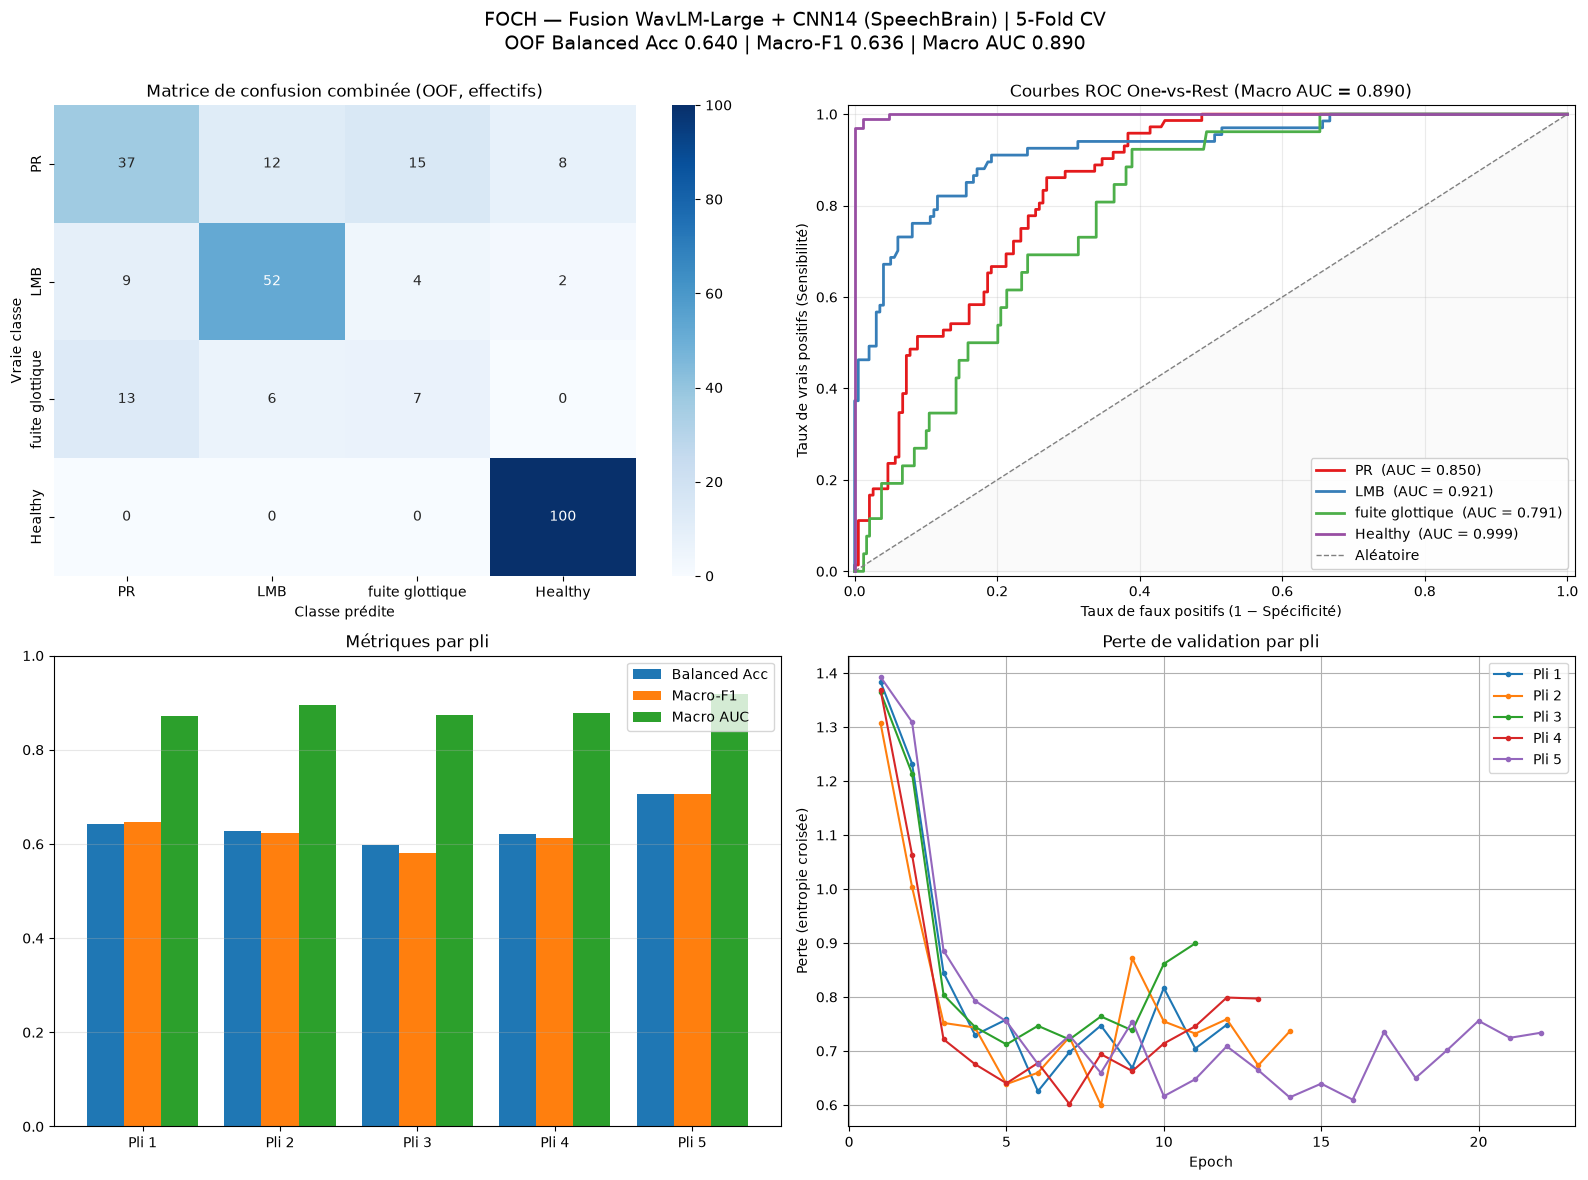


Artefacts sauvegardés dans C:/Users/AdminIA/Documents/models/.foch_métriques :
  • cnn14_kfold_aug_dashboard.png
  • cnn14_kfold_aug_metrics.json
  • cnn14_kfold_aug_confusion.csv
  • cnn14_kfold_aug_fold_metrics.csv


In [36]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 8 — Évaluation agrégée out-of-fold (K-Fold)
# ═══════════════════════════════════════════════════════════════════════════
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc as sk_auc)
from sklearn.preprocessing import label_binarize

assert (oof_labels >= 0).all(), "Des enregistrements n\'ont pas été évalués !"

# ── Métriques agrégées ────────────────────────────────────────────────────────
print('Rapport de classification agrégé (out-of-fold) :')
print('\n' + classification_report(oof_labels, oof_preds, labels=labels_idx,
                                    target_names=CLASSES, digits=3, zero_division=0))
oof_bal = balanced_accuracy_score(oof_labels, oof_preds)
oof_mf1 = f1_score(oof_labels, oof_preds, average='macro', zero_division=0)
try:
    oof_auc = roc_auc_score(oof_labels, oof_probs, multi_class='ovr',
                            average='macro', labels=labels_idx)
except ValueError:
    oof_auc = float('nan')

mean_bal, std_bal = fold_df['balanced_accuracy'].mean(), fold_df['balanced_accuracy'].std()
mean_f1,  std_f1  = fold_df['macro_f1'].mean(),          fold_df['macro_f1'].std()
mean_auc, std_auc = fold_df['macro_auc_ovr'].mean(),     fold_df['macro_auc_ovr'].std()
print(f'OOF global        — Balanced Acc {oof_bal:.4f} | Macro-F1 {oof_mf1:.4f} | Macro AUC {oof_auc:.4f}')
print(f'Moyenne par pli   — Balanced Acc {mean_bal:.4f}±{std_bal:.4f} | '
      f'Macro-F1 {mean_f1:.4f}±{std_f1:.4f} | Macro AUC {mean_auc:.4f}±{std_auc:.4f}')

# ── ROC par classe (One-vs-Rest) ──────────────────────────────────────────────
oof_labels_bin = label_binarize(oof_labels, classes=labels_idx)   # (n, 4)

# ── Tableau de bord 2×2 ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'FOCH — Fusion WavLM-Large + CNN14 (SpeechBrain) | {K_FOLDS}-Fold CV\n'
             f'OOF Balanced Acc {oof_bal:.3f} | Macro-F1 {oof_mf1:.3f} | Macro AUC {oof_auc:.3f}',
             fontsize=14)

# ── [0, 0] Matrice de confusion (effectifs bruts) ─────────────────────────────
cm = confusion_matrix(oof_labels, oof_preds, labels=labels_idx)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=CLASSES, yticklabels=CLASSES)
axes[0, 0].set_title('Matrice de confusion combinée (OOF, effectifs)')
axes[0, 0].set_ylabel('Vraie classe')
axes[0, 0].set_xlabel('Classe prédite')

# ── [0, 1] Courbes ROC OvR par classe ────────────────────────────────────────
_colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']   # rouge, bleu, vert, violet
for i, (cls, col) in enumerate(zip(CLASSES, _colors)):
    fpr, tpr, _ = roc_curve(oof_labels_bin[:, i], oof_probs[:, i])
    auc_i = sk_auc(fpr, tpr)
    axes[0, 1].plot(fpr, tpr, color=col, lw=2, label=f'{cls}  (AUC = {auc_i:.3f})')

axes[0, 1].plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--', label='Aléatoire')
axes[0, 1].fill_between([0, 1], [0, 1], alpha=0.04, color='grey')
axes[0, 1].set_xlim([-0.01, 1.01])
axes[0, 1].set_ylim([-0.01, 1.02])
axes[0, 1].set_xlabel('Taux de faux positifs (1 − Spécificité)')
axes[0, 1].set_ylabel('Taux de vrais positifs (Sensibilité)')
axes[0, 1].set_title(f'Courbes ROC One-vs-Rest (Macro AUC = {oof_auc:.3f})')
axes[0, 1].legend(loc='lower right', framealpha=0.9)
axes[0, 1].grid(True, alpha=0.25)

# ── [1, 0] Métriques par pli ──────────────────────────────────────────────────
x = np.arange(K_FOLDS); w = 0.27
axes[1, 0].bar(x - w, fold_df['balanced_accuracy'], w, label='Balanced Acc')
axes[1, 0].bar(x,     fold_df['macro_f1'],          w, label='Macro-F1')
axes[1, 0].bar(x + w, fold_df['macro_auc_ovr'],     w, label='Macro AUC')
axes[1, 0].set_title('Métriques par pli')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels([f'Pli {i+1}' for i in range(K_FOLDS)])
axes[1, 0].set_ylim(0, 1)
axes[1, 0].legend()
axes[1, 0].grid(True, axis='y', alpha=0.3)

# ── [1, 1] Perte de validation par pli ────────────────────────────────────────
for k, hist in enumerate(fold_curves):
    axes[1, 1].plot(range(1, len(hist) + 1), hist, 'o-', label=f'Pli {k+1}', markersize=3)
axes[1, 1].set_title('Perte de validation par pli')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Perte (entropie croisée)')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.subplots_adjust(top=0.90)
fig_path = os.path.join(METRICS_DIR, f'{RUN_NAME}_dashboard.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()

# ── Sauvegarde des artefacts ──────────────────────────────────────────────────
report_dict = classification_report(oof_labels, oof_preds, labels=labels_idx,
                                     target_names=CLASSES, output_dict=True, zero_division=0)
metrics = {
    'run_name':               RUN_NAME,
    'architecture':           f'DualBranchFusion (WavLM-Large + CNN14-SpeechBrain, emb_dim={CNN14_EMB_DIM})',
    'cv':                     f'StratifiedKFold(n_splits={K_FOLDS})',
    'oof_balanced_accuracy':  oof_bal,
    'oof_macro_f1':           oof_mf1,
    'oof_macro_auc_ovr':      oof_auc,
    'mean_balanced_accuracy': mean_bal, 'std_balanced_accuracy': std_bal,
    'mean_macro_f1':          mean_f1,  'std_macro_f1':          std_f1,
    'mean_macro_auc_ovr':     mean_auc, 'std_macro_auc_ovr':     std_auc,
    'per_fold':               fold_rows,
    'per_class_oof':          report_dict,
    'classes':                CLASSES,
    'n_total':                int(len(df)),
}
with open(os.path.join(METRICS_DIR, f'{RUN_NAME}_metrics.json'), 'w', encoding='utf-8') as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2, default=float)
np.savetxt(os.path.join(METRICS_DIR, f'{RUN_NAME}_confusion.csv'), cm, fmt='%d', delimiter=',')
fold_df.to_csv(os.path.join(METRICS_DIR, f'{RUN_NAME}_fold_metrics.csv'), index=False)

print(f'\nArtefacts sauvegardés dans {METRICS_DIR} :')
print(f'  • {RUN_NAME}_dashboard.png')
print(f'  • {RUN_NAME}_metrics.json')
print(f'  • {RUN_NAME}_confusion.csv')
print(f'  • {RUN_NAME}_fold_metrics.csv')


## 8b. Comparaison et fusion tardive : neuronal vs RC vs ensemble

Combine les probabilités out-of-fold du modèle neuronal (`oof_probs`, Cellule 7) et de la branche RC
(`rc_oof_probs`, Cellule 6d) par **simple moyenne** — mêmes plis, mêmes patients de validation dans
les deux cas, donc directement comparables. Rapporte balanced accuracy / macro-F1 / macro AUC pour
les trois configurations (neuronal seul, RC seul, ensemble), afin de juger si la branche RC apporte
un gain avant de l'intégrer durablement au pipeline.

**Prérequis : cette cellule nécessite que la Cellule 7 ait été exécutée** (elle produit `oof_probs`/
`oof_preds`/`oof_labels`) — non lancée à ce stade car l'entraînement K-Fold complet du modèle
neuronal est coûteux.

In [37]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 8b — Fusion tardive : neuronal (Cellule 7) + RC (Cellule 6d)
# ═══════════════════════════════════════════════════════════════════════════
# Nécessite que la Cellule 7 (boucle neuronale) ait été exécutée : `oof_labels`/
# `oof_preds`/`oof_probs` proviennent de cette cellule. La branche RC (`rc_oof_*`)
# est indépendante et déjà disponible dès la Cellule 6d.
assert 'oof_probs' in globals(), (
    "oof_probs introuvable : exécutez d'abord la Cellule 7 (boucle neuronale) "
    "avant cette cellule de fusion tardive.")
assert (oof_labels >= 0).all(), "Cellule 7 incomplète : tous les plis n'ont pas produit d'OOF."
assert np.array_equal(oof_labels, rc_oof_labels), (
    "Désalignement entre les labels OOF neuronaux et RC — plis incohérents !")

ensemble_probs = (oof_probs + rc_oof_probs) / 2.0
ensemble_preds = ensemble_probs.argmax(axis=1)


def _report(name, labels, preds, probs):
    bal = balanced_accuracy_score(labels, preds)
    mf1 = f1_score(labels, preds, average='macro', zero_division=0)
    try:
        auc = roc_auc_score(labels, probs, multi_class='ovr', average='macro', labels=labels_idx)
    except ValueError:
        auc = float('nan')
    print(f'{name:<28} — Balanced Acc {bal:.4f} | Macro-F1 {mf1:.4f} | Macro AUC {auc:.4f}')
    return {'branch': name, 'balanced_accuracy': bal, 'macro_f1': mf1, 'macro_auc_ovr': auc}


print('Comparaison out-of-fold (mêmes plis, mêmes patients de validation) :')
comparison_rows = [
    _report('Neuronal seul (WavLM+CNN14)', oof_labels, oof_preds, oof_probs),
    _report('RC seul',                     rc_oof_labels, rc_oof_preds, rc_oof_probs),
    _report('Ensemble (moyenne 50/50)',     oof_labels, ensemble_preds, ensemble_probs),
]
comparison_df = pd.DataFrame(comparison_rows)
comparison_df

Comparaison out-of-fold (mêmes plis, mêmes patients de validation) :
Neuronal seul (WavLM+CNN14)  — Balanced Acc 0.6398 | Macro-F1 0.6364 | Macro AUC 0.8904
RC seul                      — Balanced Acc 0.3382 | Macro-F1 0.2683 | Macro AUC 0.6144
Ensemble (moyenne 50/50)     — Balanced Acc 0.6112 | Macro-F1 0.6057 | Macro AUC 0.8827


,branch,balanced_accuracy,macro_f1,macro_auc_ovr
0,Neuronal seul (WavLM+CNN14),0.639810,0.636405,0.890398
1,RC seul,0.338194,0.268305,0.614414
2,Ensemble (moyenne 50/50),0.611247,0.605662,0.882714


## 9. Synthèse et prochaines étapes

Ce notebook met en œuvre un **modèle de fusion bi-branche** (WavLM-Large + CNN14 SpeechBrain) évalué par **validation croisée stratifiée à 5 plis**, avec **augmentation de données** injectée pli par pli.

**Choix méthodologiques clés :**
- **Fusion de deux vues complémentaires** : embeddings WavLM 1024-d (microscopique) ⊕ CNN14 2048-d sur Mel (macroscopique) → 3072-d.
- **CNN14 audio-natif** : pré-entraîné sur ~2M clips AudioSet (puis affiné ESC-50), il encode harmoniques, formants et structures de bruit — directement pertinent pour la pathologie laryngée, contrairement aux textures RGB d'ImageNet.
- **Entrée native mono-canal** : CNN14 opère sur `(B, T, mel_bins)` sans réplication sur 3 canaux (permutation `squeeze(1).permute(0, 2, 1)` dans le `forward`).
- **Chargement partiel** : la couche `norm0` (mel_bins=80 dans ESC-50 vs 128 ici) est réinitialisée ; tous les blocs convolutifs chargent leurs poids audio-pré-entraînés.
- **Validation croisée K-Fold** : métriques OOF + moyenne ± écart-type par pli.
- **Augmentation sans fuite** : segments injectés uniquement dans le train, patients de validation exclus.

**Pistes d'amélioration ultérieures :**
1. Recalibrer `N_MELS = 80` pour correspondre exactement au modèle ESC-50 et charger `norm0` intégralement.
2. Explorer `emb_dim=1024` pour réduire la dimension de fusion à 2048 et alléger la tête.
3. **Dégel progressif** de WavLM (*progressive unfreezing*).
4. **SpecAugment** sur la branche Mel.
5. **Ensembling** des K modèles de plis à l'inférence.
6. **Audit qualité** des doublons d'homonymes (`MARTIN`) via `patient_id`.

> ⚠️ **Rappel d'exécution** — cellules à exécuter **dans l'ordre** (1 → 8). La Cellule 6 télécharge le checkpoint CNN14 depuis HuggingFace Hub (`speechbrain/cnn14-esc50`) au premier lancement. La Cellule 7 entraîne **K = 5 modèles** (WavLM gelé + CNN14 + tête) : prévoir un GPU CUDA et un temps d'exécution conséquent.
